# 🌡️ Salvador Temperature Threshold Analysis

This notebook explores the impact of different temperature thresholds on extreme heat day counts for Salvador, Brazil metropolitan area.

## 📋 Analysis Plan:
1. **Data Source:** GSHTD (Global Surface Heat Temperature Dataset) - both TMIN and TMAX
2. **Location:** Salvador metropolitan area, Brazil
3. **Temperature Metric:** Average temperature = (TMAX + TMIN) / 2
4. **Thresholds:** 25°C, 28°C, 30°C
5. **Visualizations:** 
   - Time series of min, max, and average temperatures
   - Time series of heat day counts by threshold

## 🎯 Research Question:
How does the choice of temperature threshold affect the count of extreme heat days in Salvador?

In [3]:
# Import required libraries
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 12

# Initialize Google Earth Engine
try:
    ee.Initialize(project='tl-cities')
    print('✅ Google Earth Engine initialized successfully')
except Exception as e:
    print(f'❌ GEE initialization failed: {e}')

print('📦 All packages loaded successfully')
print('🌡️ Salvador Temperature Threshold Analysis Ready!')

✅ Google Earth Engine initialized successfully
📦 All packages loaded successfully
🌡️ Salvador Temperature Threshold Analysis Ready!


## 🎯 Step 1: Define Salvador Metropolitan Area

In [4]:
# --- ROI source ---
# Change the single line below to select how the study area is defined:
#
#   ROI_SOURCE = 'coordinates'    # hardcoded bounding box (default, works immediately)
#   ROI_SOURCE = 'geobr'          # derive bbox from Salvador neighbourhood boundaries
#                                  # (requires: pip install geobr)
#   ROI_SOURCE = 'draw'           # draw a rectangle or polygon on the interactive map,
#                                  # then re-run this cell to capture it
#
ROI_SOURCE = 'coordinates'

# Hardcoded fallback / default bounding box (used when ROI_SOURCE = 'coordinates')
_COORDS = {'west': -38.8, 'east': -38.2, 'south': -13.2, 'north': -12.7}

# Shared cache for geobr neighbourhood download (also used by the neighbourhood cell below)
GEOBR_CACHE = '../data/geobr_salvador_neighbourhoods_2010.gpkg'
_SALVADOR_CODE = 2927408  # IBGE municipality code for Salvador


def _load_geobr_neighbourhoods(year=2010, cache_path=GEOBR_CACHE):
    """
    Return Salvador neighbourhood boundaries as a GeoDataFrame (EPSG:4326).
    Loads from cache if available; downloads from geobr and saves cache otherwise.
    """
    import geopandas as gpd

    if os.path.exists(cache_path):
        print(f'Loading cached geobr boundaries: {cache_path}')
        return gpd.read_file(cache_path)

    from geobr import read_neighborhood
    print(f'Downloading Salvador neighbourhood boundaries from geobr (year={year}) ...')
    gdf_all = read_neighborhood(year=year, simplified=True)
    gdf = gdf_all[gdf_all['code_muni'] == _SALVADOR_CODE].copy()
    if gdf.empty:
        raise ValueError(f'No neighbourhoods found for code {_SALVADOR_CODE}.')
    if gdf.crs and gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs('EPSG:4326')

    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    gdf.to_file(cache_path, driver='GPKG')
    print(f'Cached to {cache_path}')
    return gdf


def _roi_from_coords(coords):
    geom = ee.Geometry.Rectangle(
        [coords['west'], coords['south'], coords['east'], coords['north']]
    )
    label = (f"{coords['south']}°S to {coords['north']}°S, "
             f"{abs(coords['west'])}°W to {abs(coords['east'])}°W")
    return geom, label


def _roi_from_geobr():
    """Dissolve Salvador neighbourhood polygons to a bounding envelope for GEE."""
    from shapely.ops import unary_union
    gdf = _load_geobr_neighbourhoods()
    dissolved = unary_union(gdf.geometry)
    minx, miny, maxx, maxy = dissolved.bounds
    buf = 0.02  # small buffer so GEE edge pixels are included
    geom = ee.Geometry.Rectangle([minx - buf, miny - buf, maxx + buf, maxy + buf])
    label = f'geobr envelope ({len(gdf)} neighbourhoods, 2010)'
    return geom, label


def _roi_from_drawing(m):
    """Extract the last shape drawn on map m. Returns (None, None) if nothing drawn yet."""
    try:
        drawn = m.draw_last_feature
        if drawn and drawn.geometry:
            coords_list = drawn.geometry.coordinates
            if drawn.geometry.type == 'Polygon':
                geom = ee.Geometry.Polygon(coords_list)
            else:
                geom = ee.Geometry.Rectangle(coords_list)
            return geom, 'drawn on map'
    except Exception:
        pass
    return None, None


# Build the map first so drawing tools are available before ROI is captured
m = geemap.Map(center=[-12.95, -38.5], zoom=9)
m.add_basemap('SATELLITE')

if ROI_SOURCE == 'draw':
    print('Draw mode: use the rectangle or polygon tool on the map below.')
    print('After drawing, re-run this cell to capture the shape as salvador_roi.')
    roi_geom, roi_label = _roi_from_drawing(m)
    if roi_geom is None:
        print('Nothing drawn yet - defaulting to coordinate bbox until you draw and re-run.')
        roi_geom, roi_label = _roi_from_coords(_COORDS)
elif ROI_SOURCE == 'geobr':
    roi_geom, roi_label = _roi_from_geobr()
else:
    roi_geom, roi_label = _roi_from_coords(_COORDS)

salvador_roi = roi_geom
area_km2 = salvador_roi.area().divide(1_000_000).getInfo()

print(f'ROI source  : {ROI_SOURCE}')
print(f'Definition  : {roi_label}')
print(f'Area        : {area_km2:.1f} km²')

roi_style = {'color': 'red', 'fillColor': 'red', 'fillOpacity': 0.15, 'width': 2}
m.addLayer(salvador_roi, roi_style, 'Study area ROI')
m.addLayer(ee.Geometry.Point([-38.5014, -12.9714]), {'color': 'yellow'}, 'Salvador city centre')
display(m)


ROI source  : coordinates
Definition  : -13.2°S to -12.7°S, 38.8°W to 38.2°W
Area        : 3615.0 km²


Map(center=[-12.95, -38.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

## 📊 Step 2: Analysis Configuration

In [5]:
# --- Analysis parameters ---
# Edit these values before running the Step 3 extraction.
# If you change ANALYSIS_START / ANALYSIS_END, delete the cache files and re-run Step 3.

ANALYSIS_START = '2018-01-01'
ANALYSIS_END   = '2020-12-31'
TEMPERATURE_THRESHOLDS = [25, 28, 30]   # for time-series steps 4-10
RESOLUTION     = 1000                   # GEE extraction resolution in metres

# Shared cache paths - written once in Step 3, read by all later cells
TMAX_SPATIAL_CACHE = '../data/gshtd_tmax_salvador_spatial.nc'
TMIN_SPATIAL_CACHE = '../data/gshtd_tmin_salvador_spatial.nc'
BASELINE_END_YEAR  = 2020   # inclusive upper bound for relative-threshold baseline

print(f'Analysis period : {ANALYSIS_START}  to  {ANALYSIS_END}')
print(f'Resolution      : {RESOLUTION} m')
print(f'Tmax cache      : {TMAX_SPATIAL_CACHE}')


Analysis period : 2018-01-01  to  2020-12-31
Resolution      : 1000 m
Tmax cache      : ../data/gshtd_tmax_salvador_spatial.nc


## 📡 Step 3: Extract GSHTD Temperature Data

In [6]:
import os

GSHTD_COLLECTION = 'projects/sat-io/open-datasets/global-daily-air-temp/latin_america'


def _pivot_to_xarray(df, varname):
    """Pivot flat (date, lat, lon, value) DataFrame to xr.DataArray (time, lat, lon)."""
    df = df.copy()
    df['latitude']  = df['latitude'].round(4)
    df['longitude'] = df['longitude'].round(4)
    df['date'] = pd.to_datetime(df['date'])

    pivot = df.pivot_table(index='date', columns=['latitude', 'longitude'],
                           values=varname, aggfunc='mean')
    lats  = sorted(pivot.columns.get_level_values(0).unique())
    lons  = sorted(pivot.columns.get_level_values(1).unique())
    times = pivot.index.values

    arr = np.full((len(times), len(lats), len(lons)), np.nan, dtype=np.float32)
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            if (lat, lon) in pivot.columns:
                arr[:, i, j] = pivot[(lat, lon)].values

    import xarray as xr
    return xr.DataArray(arr, dims=['time', 'lat', 'lon'],
                        coords={'time': times, 'lat': lats, 'lon': lons},
                        name=varname,
                        attrs={'units': 'degC', 'source': 'GSHTD'})


def _extract_variable(collection, varname):
    """Pull per-pixel daily data from GEE in 90-day chunks. Returns flat DataFrame."""
    start = datetime.strptime(ANALYSIS_START, '%Y-%m-%d')
    end   = datetime.strptime(ANALYSIS_END,   '%Y-%m-%d')
    chunks = []
    cur = start
    while cur <= end:
        chunk_end = min(cur + timedelta(days=90), end)
        col = collection.filterDate(cur.strftime('%Y-%m-%d'), chunk_end.strftime('%Y-%m-%d'))
        if col.size().getInfo() == 0:
            cur = chunk_end + timedelta(days=1)
            continue
        processed = col.map(lambda img:
            img.select('b1').divide(10).rename(varname)
               .clip(salvador_roi).copyProperties(img, ['system:time_start']))
        try:
            raw = processed.getRegion(geometry=salvador_roi,
                                      scale=RESOLUTION, crs='EPSG:4326').getInfo()
            if len(raw) > 1:
                df = pd.DataFrame(raw[1:], columns=raw[0])
                df['time'] = pd.to_datetime(df['time'], unit='ms')
                df['date'] = df['time'].dt.date
                df = df.dropna(subset=[varname])
                df['latitude']  = df['latitude'].astype(float)
                df['longitude'] = df['longitude'].astype(float)
                df[varname]     = df[varname].astype(float)
                chunks.append(df)
                print(f'  {cur.strftime("%Y-%m-%d")} - {chunk_end.strftime("%Y-%m-%d")}: {len(df):,} rows')
        except Exception as e:
            print(f'  Chunk failed: {e}')
        cur = chunk_end + timedelta(days=1)
    return pd.concat(chunks, ignore_index=True) if chunks else None


def extract_temperature_data_salvador(force_refresh=False):
    """
    Download TMIN and TMAX from GSHTD for the configured period and ROI.

    On first run this contacts GEE and may take 10-30 min depending on date range.
    Results are cached as NetCDF (spatial) and used by all downstream cells, so
    subsequent runs skip the download entirely.

    Returns a spatially-averaged daily DataFrame (tmin, tmax, tavg) for Steps 4-10.
    Spatial NetCDFs for the neighbourhood analysis are written to TMAX_SPATIAL_CACHE
    and TMIN_SPATIAL_CACHE and loaded automatically by Step 11+.
    """
    both_cached = (os.path.exists(TMAX_SPATIAL_CACHE) and
                   os.path.exists(TMIN_SPATIAL_CACHE))

    if not force_refresh and both_cached:
        print('Spatial caches found - loading from disk (no GEE download needed).')
        import xarray as xr
        tmax_da = xr.open_dataset(TMAX_SPATIAL_CACHE)['tmax']
        tmin_da = xr.open_dataset(TMIN_SPATIAL_CACHE)['tmin']
        # Derive spatially-averaged daily time series
        tmax_avg = tmax_da.mean(dim=['lat', 'lon']).to_series().rename('tmax')
        tmin_avg = tmin_da.mean(dim=['lat', 'lon']).to_series().rename('tmin')
        df = pd.concat([tmin_avg, tmax_avg], axis=1).dropna().reset_index()
        df.columns = ['date', 'tmin', 'tmax']
        df['date'] = pd.to_datetime(df['date'])
        df['tavg'] = (df['tmax'] + df['tmin']) / 2
        print(f'Loaded {len(df)} days: {df["date"].min().date()} to {df["date"].max().date()}')
        return df.sort_values('date').reset_index(drop=True)

    print('Connecting to GEE for GSHTD download...')
    base = ee.ImageCollection(GSHTD_COLLECTION)
    filtered = (base.filterDate(ANALYSIS_START, ANALYSIS_END)
                    .filterBounds(salvador_roi))

    tmax_col = filtered.filter(ee.Filter.eq('prop_type', 'tmax'))
    tmin_col = filtered.filter(ee.Filter.eq('prop_type', 'tmin'))
    print(f'TMAX images: {tmax_col.size().getInfo()}   '
          f'TMIN images: {tmin_col.size().getInfo()}')

    print('Downloading TMAX ...')
    tmax_df = _extract_variable(tmax_col, 'tmax')
    print('Downloading TMIN ...')
    tmin_df = _extract_variable(tmin_col, 'tmin')

    if tmax_df is None or tmin_df is None:
        raise RuntimeError('GEE extraction failed - check connection and re-run.')

    # Save spatial NetCDFs (used by neighbourhood analysis cells)
    os.makedirs('../data', exist_ok=True)
    _pivot_to_xarray(tmax_df, 'tmax').to_dataset().to_netcdf(TMAX_SPATIAL_CACHE)
    _pivot_to_xarray(tmin_df, 'tmin').to_dataset().to_netcdf(TMIN_SPATIAL_CACHE)
    print(f'Spatial caches saved: {TMAX_SPATIAL_CACHE}')

    # Return spatially-averaged daily DataFrame for Steps 4-10
    tmax_avg = tmax_df.groupby('date')['tmax'].mean()
    tmin_avg = tmin_df.groupby('date')['tmin'].mean()
    df = pd.concat([tmin_avg, tmax_avg], axis=1).dropna().reset_index()
    df['date'] = pd.to_datetime(df['date'])
    df['tavg'] = (df['tmax'] + df['tmin']) / 2
    return df.sort_values('date').reset_index(drop=True)


salvador_temp_data = extract_temperature_data_salvador()
print(f'\nTmax: {salvador_temp_data["tmax"].min():.1f} - {salvador_temp_data["tmax"].max():.1f} °C  |  '
      f'Tmin: {salvador_temp_data["tmin"].min():.1f} - {salvador_temp_data["tmin"].max():.1f} °C')


Spatial caches found - loading from disk (no GEE download needed).
Loaded 1083 days: 2018-01-01 to 2020-12-30

Tmax: -5.5 - 71.1 °C  |  Tmin: 10.9 - 32.2 °C


## 📈 Step 4: Temperature Time Series Visualization

📈 Creating temperature time series visualization...


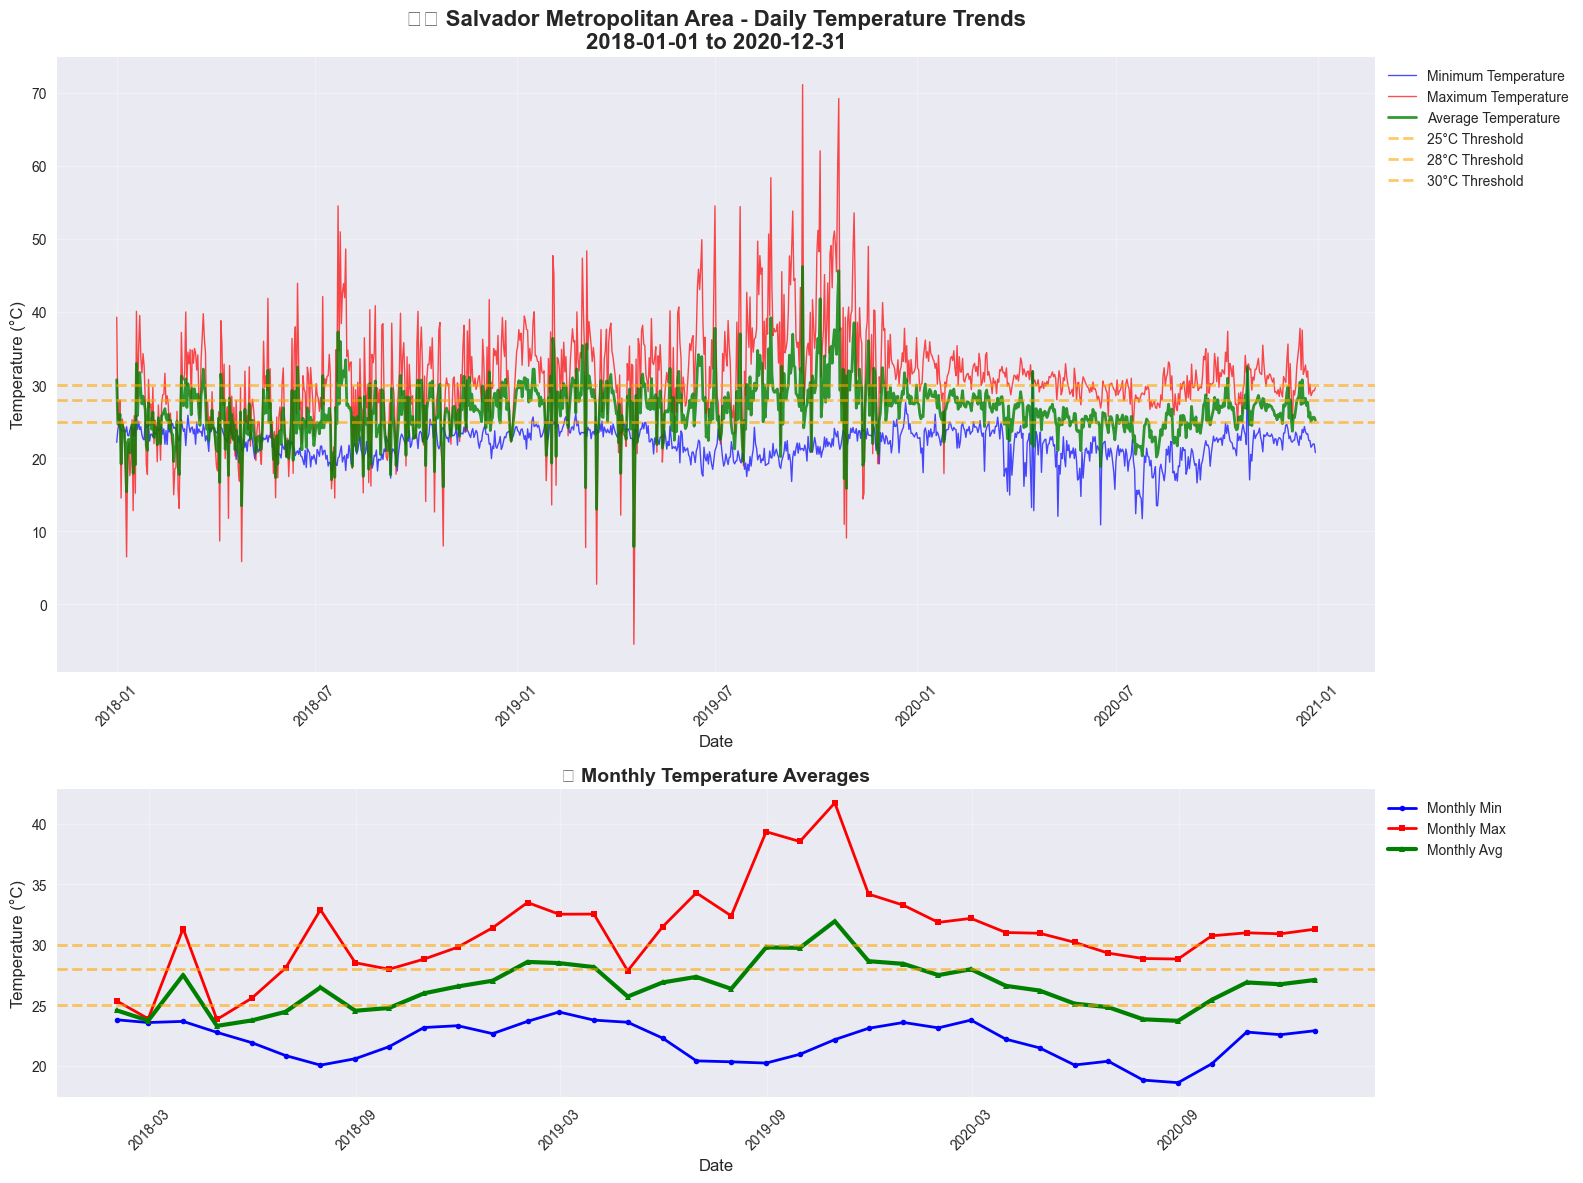


📊 TEMPERATURE STATISTICS:
Minimum Temperature  - Mean: 22.0°C, Range: 10.9 to 32.2°C
Maximum Temperature  - Mean: 31.0°C, Range: -5.5 to 71.1°C
Average Temperature  - Mean: 26.5°C, Range: 7.9 to 46.2°C
Daily Temperature Range - Mean: 9.0°C


In [7]:
def plot_temperature_time_series(temp_data):
    """
    Create time series plot showing min, max, and average temperatures
    """
    if temp_data is None:
        print('❌ No temperature data available for plotting')
        return
    
    print('📈 Creating temperature time series visualization...')
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), 
                                   gridspec_kw={'height_ratios': [2, 1]})
    
    # Plot 1: Full time series
    ax1.plot(temp_data['date'], temp_data['tmin'], 
             color='blue', alpha=0.7, linewidth=1, label='Minimum Temperature')
    ax1.plot(temp_data['date'], temp_data['tmax'], 
             color='red', alpha=0.7, linewidth=1, label='Maximum Temperature')
    ax1.plot(temp_data['date'], temp_data['tavg'], 
             color='green', linewidth=2, label='Average Temperature', alpha=0.8)
    
    # Add threshold lines
    for threshold in TEMPERATURE_THRESHOLDS:
        ax1.axhline(y=threshold, color='orange', linestyle='--', alpha=0.6, 
                   linewidth=2, label=f'{threshold}°C Threshold')
    
    ax1.set_title('🌡️ Salvador Metropolitan Area - Daily Temperature Trends\n' + 
                  f'{ANALYSIS_START} to {ANALYSIS_END}', fontsize=16, fontweight='bold')
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('Temperature (°C)', fontsize=12)
    ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax1.grid(True, alpha=0.3)
    
    # Format x-axis
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    
    # Plot 2: Monthly averages for clearer seasonal patterns
    monthly_data = temp_data.set_index('date').resample('M').mean()
    
    ax2.plot(monthly_data.index, monthly_data['tmin'], 
             color='blue', marker='o', linewidth=2, markersize=4, label='Monthly Min')
    ax2.plot(monthly_data.index, monthly_data['tmax'], 
             color='red', marker='s', linewidth=2, markersize=4, label='Monthly Max')
    ax2.plot(monthly_data.index, monthly_data['tavg'], 
             color='green', marker='^', linewidth=3, markersize=5, label='Monthly Avg')
    
    # Add threshold lines
    for threshold in TEMPERATURE_THRESHOLDS:
        ax2.axhline(y=threshold, color='orange', linestyle='--', alpha=0.6, linewidth=2)
    
    ax2.set_title('📊 Monthly Temperature Averages', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_ylabel('Temperature (°C)', fontsize=12)
    ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax2.grid(True, alpha=0.3)
    
    # Format x-axis for monthly plot
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print temperature statistics
    print('\n📊 TEMPERATURE STATISTICS:')
    print('='*50)
    print(f'Minimum Temperature  - Mean: {temp_data["tmin"].mean():.1f}°C, Range: {temp_data["tmin"].min():.1f} to {temp_data["tmin"].max():.1f}°C')
    print(f'Maximum Temperature  - Mean: {temp_data["tmax"].mean():.1f}°C, Range: {temp_data["tmax"].min():.1f} to {temp_data["tmax"].max():.1f}°C')
    print(f'Average Temperature  - Mean: {temp_data["tavg"].mean():.1f}°C, Range: {temp_data["tavg"].min():.1f} to {temp_data["tavg"].max():.1f}°C')
    print(f'Daily Temperature Range - Mean: {(temp_data["tmax"] - temp_data["tmin"]).mean():.1f}°C')

# Create the temperature time series plot
if salvador_temp_data is not None:
    plot_temperature_time_series(salvador_temp_data)
else:
    print('❌ No temperature data available. Please extract data first.')

## 🔥 Step 5: Heat Days Calculation and Analysis

In [8]:
def calculate_heat_days_by_threshold(temp_data, thresholds):
    """
    Calculate heat days for different temperature thresholds
    Heat day = day when average temperature > threshold
    """
    if temp_data is None:
        print('❌ No temperature data available')
        return None
    
    print(f'🔥 Calculating heat days for thresholds: {thresholds}°C')
    
    # Create copy of data for calculations
    heat_data = temp_data.copy()
    
    # Add year and month columns for aggregation
    heat_data['year'] = heat_data['date'].dt.year
    heat_data['month'] = heat_data['date'].dt.month
    heat_data['year_month'] = heat_data['date'].dt.to_period('M')
    
    # Calculate heat days for each threshold
    for threshold in thresholds:
        heat_data[f'heat_day_{threshold}C'] = (heat_data['tavg'] > threshold).astype(int)
    
    print('   ✅ Heat days calculated for all thresholds')
    
    # Calculate monthly heat day counts
    agg_dict = {}
    for threshold in thresholds:
        agg_dict[f'heat_day_{threshold}C'] = 'sum'
    
    # Add temperature aggregations
    agg_dict.update({
        'tavg': ['mean', 'max', 'min'],
        'tmax': 'max',
        'tmin': 'min'
    })
    
    monthly_heat_days = heat_data.groupby('year_month').agg(agg_dict).reset_index()
    
    # Flatten column names properly
    new_columns = []
    for col in monthly_heat_days.columns:
        if isinstance(col, tuple):
            if col[1] == '' or col[1] == 'sum':
                new_columns.append(col[0])
            else:
                new_columns.append(f'{col[0]}_{col[1]}')
        else:
            new_columns.append(col)
    
    monthly_heat_days.columns = new_columns
    
    # Convert period back to datetime for plotting
    monthly_heat_days['date'] = monthly_heat_days['year_month'].dt.to_timestamp()
    
    # Calculate annual heat day counts
    annual_agg_dict = {}
    for threshold in thresholds:
        annual_agg_dict[f'heat_day_{threshold}C'] = 'sum'
    annual_agg_dict['tavg'] = 'mean'
    
    annual_heat_days = heat_data.groupby('year').agg(annual_agg_dict).reset_index()
    
    print('   ✅ Monthly and annual aggregations complete')
    
    # Print summary statistics
    print('\\n🔥 HEAT DAYS SUMMARY:')
    print('='*60)
    
    for threshold in thresholds:
        col_name = f'heat_day_{threshold}C'
        total_days = heat_data[col_name].sum()
        percentage = (total_days / len(heat_data)) * 100
        annual_avg = annual_heat_days[col_name].mean()
        
        # Check if column exists in monthly data before accessing
        if col_name in monthly_heat_days.columns:
            monthly_max = monthly_heat_days[col_name].max()
        else:
            monthly_max = 0
            print(f'   ⚠️ Column {col_name} not found in monthly data')
        
        print(f'{threshold}°C Threshold:')
        print(f'   Total heat days: {total_days:,} ({percentage:.1f}% of all days)')
        print(f'   Average per year: {annual_avg:.1f} days')
        print(f'   Max in one month: {monthly_max:.0f} days')
        print()
    
    # Debug: Print column names
    print('📊 Debug - Monthly data columns:')
    print(f'   {list(monthly_heat_days.columns)}')
    print()
    
    return heat_data, monthly_heat_days, annual_heat_days

# Calculate heat days
if salvador_temp_data is not None:
    heat_results = calculate_heat_days_by_threshold(salvador_temp_data, TEMPERATURE_THRESHOLDS)
    
    if heat_results:
        daily_heat_data, monthly_heat_data, annual_heat_data = heat_results
        print('✅ Heat days calculation complete')
    else:
        print('❌ Heat days calculation failed')
else:
    print('❌ No temperature data available for heat days calculation')

🔥 Calculating heat days for thresholds: [25, 28, 30]°C
   ✅ Heat days calculated for all thresholds
   ✅ Monthly and annual aggregations complete
\n🔥 HEAT DAYS SUMMARY:
25°C Threshold:
   Total heat days: 751 (69.3% of all days)
   Average per year: 250.3 days
   Max in one month: 30 days

28°C Threshold:
   Total heat days: 341 (31.5% of all days)
   Average per year: 113.7 days
   Max in one month: 26 days

30°C Threshold:
   Total heat days: 140 (12.9% of all days)
   Average per year: 46.7 days
   Max in one month: 20 days

📊 Debug - Monthly data columns:
   ['year_month', 'heat_day_25C', 'heat_day_28C', 'heat_day_30C', 'tavg_mean', 'tavg_max', 'tavg_min', 'tmax_max', 'tmin_min', 'date']

✅ Heat days calculation complete


## 📊 Step 6: Heat Days Time Series Visualization

📊 Creating heat days time series visualization...


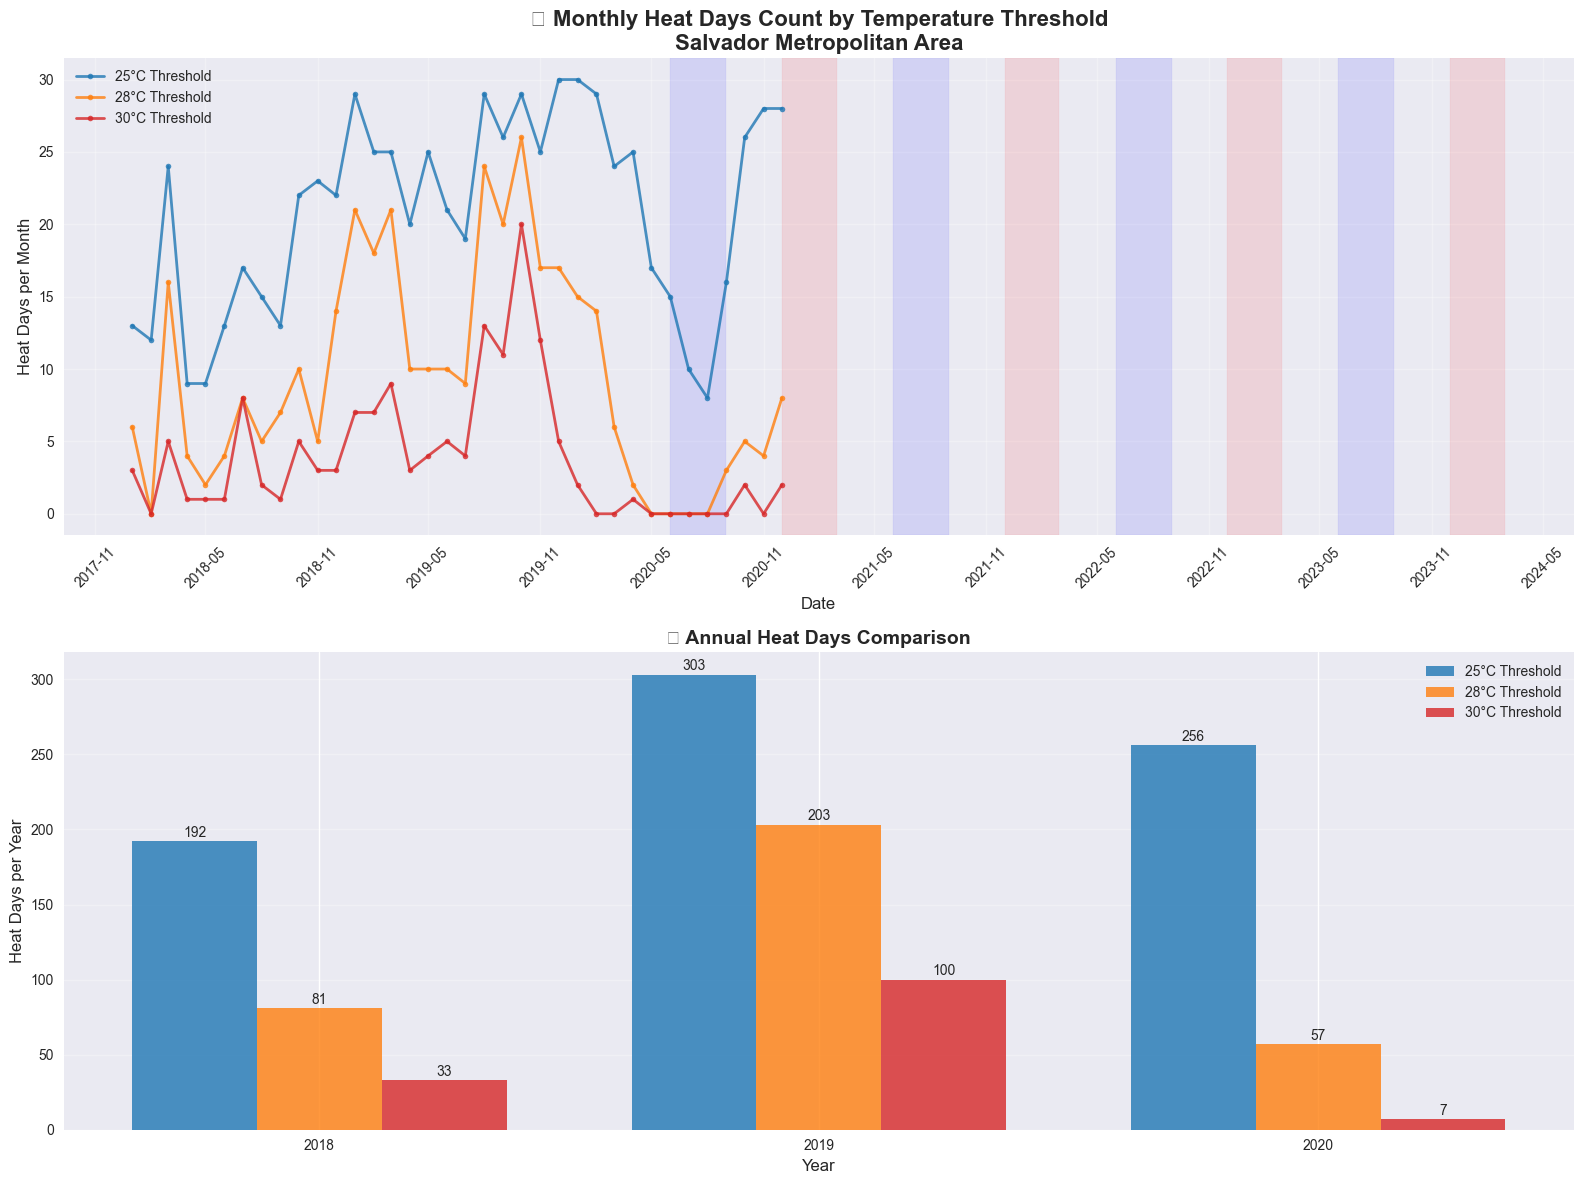


📊 THRESHOLD COMPARISON SUMMARY:
25°C Threshold:
   Average per month: 20.9 days
   Maximum in one month: 30 days
   Average per year: 250.3 days

28°C Threshold:
   Average per month: 9.5 days
   Maximum in one month: 26 days
   Average per year: 113.7 days
   Reduction from 25°C: 136.7 days/year (54.6%)

30°C Threshold:
   Average per month: 3.9 days
   Maximum in one month: 20 days
   Average per year: 46.7 days
   Reduction from 28°C: 67.0 days/year (58.9%)



In [9]:
def plot_heat_days_time_series(monthly_data, annual_data, thresholds):
    """
    Create time series plots showing heat day counts by threshold
    """
    if monthly_data is None or annual_data is None:
        print('❌ No heat days data available for plotting')
        return
    
    print('📊 Creating heat days time series visualization...')
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
    
    # Define colors for each threshold
    colors = ['#1f77b4', '#ff7f0e', '#d62728']  # Blue, Orange, Red
    
    # Plot 1: Monthly heat days
    for i, threshold in enumerate(thresholds):
        col_name = f'heat_day_{threshold}C'
        ax1.plot(monthly_data['date'], monthly_data[col_name], 
                color=colors[i], marker='o', linewidth=2, markersize=4,
                label=f'{threshold}°C Threshold', alpha=0.8)
    
    ax1.set_title('🔥 Monthly Heat Days Count by Temperature Threshold\n' + 
                  'Salvador Metropolitan Area', fontsize=16, fontweight='bold')
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('Heat Days per Month', fontsize=12)
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Format x-axis
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    
    # Add seasonal shading (approximate for Southern Hemisphere)
    # Summer: Dec-Feb, Winter: Jun-Aug
    for year in range(2020, 2024):
        # Summer (hot season)
        summer_start = pd.Timestamp(f'{year}-12-01')
        summer_end = pd.Timestamp(f'{year+1}-03-01')
        ax1.axvspan(summer_start, summer_end, alpha=0.1, color='red', label='Summer' if year == 2020 else '')
        
        # Winter (cool season)
        winter_start = pd.Timestamp(f'{year}-06-01')
        winter_end = pd.Timestamp(f'{year}-09-01')
        ax1.axvspan(winter_start, winter_end, alpha=0.1, color='blue', label='Winter' if year == 2020 else '')
    
    # Plot 2: Annual heat days comparison
    x_positions = range(len(annual_data))
    bar_width = 0.25
    
    for i, threshold in enumerate(thresholds):
        col_name = f'heat_day_{threshold}C'
        x_pos = [x + i * bar_width for x in x_positions]
        ax2.bar(x_pos, annual_data[col_name], bar_width, 
               label=f'{threshold}°C Threshold', color=colors[i], alpha=0.8)
    
    ax2.set_title('📅 Annual Heat Days Comparison', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Year', fontsize=12)
    ax2.set_ylabel('Heat Days per Year', fontsize=12)
    ax2.set_xticks([x + bar_width for x in x_positions])
    ax2.set_xticklabels(annual_data['year'])
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, threshold in enumerate(thresholds):
        col_name = f'heat_day_{threshold}C'
        x_pos = [x + i * bar_width for x in x_positions]
        for j, v in enumerate(annual_data[col_name]):
            ax2.text(x_pos[j], v + 1, str(int(v)), ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Create threshold comparison summary
    print('\n📊 THRESHOLD COMPARISON SUMMARY:')
    print('='*70)
    
    for i, threshold in enumerate(thresholds):
        col_name = f'heat_day_{threshold}C'
        monthly_avg = monthly_data[col_name].mean()
        monthly_max = monthly_data[col_name].max()
        annual_avg = annual_data[col_name].mean()
        
        print(f'{threshold}°C Threshold:')
        print(f'   Average per month: {monthly_avg:.1f} days')
        print(f'   Maximum in one month: {monthly_max:.0f} days')
        print(f'   Average per year: {annual_avg:.1f} days')
        
        if i > 0:  # Compare with previous threshold
            prev_threshold = thresholds[i-1]
            prev_col = f'heat_day_{prev_threshold}C'
            reduction = annual_data[prev_col].mean() - annual_avg
            reduction_pct = (reduction / annual_data[prev_col].mean()) * 100
            print(f'   Reduction from {prev_threshold}°C: {reduction:.1f} days/year ({reduction_pct:.1f}%)')
        print()

# Create the heat days visualization
if 'monthly_heat_data' in locals() and 'annual_heat_data' in locals():
    plot_heat_days_time_series(monthly_heat_data, annual_heat_data, TEMPERATURE_THRESHOLDS)
else:
    print('❌ Heat days data not available. Please calculate heat days first.')

## 📈 Step 7: Threshold Sensitivity Analysis

📈 Creating threshold sensitivity analysis...


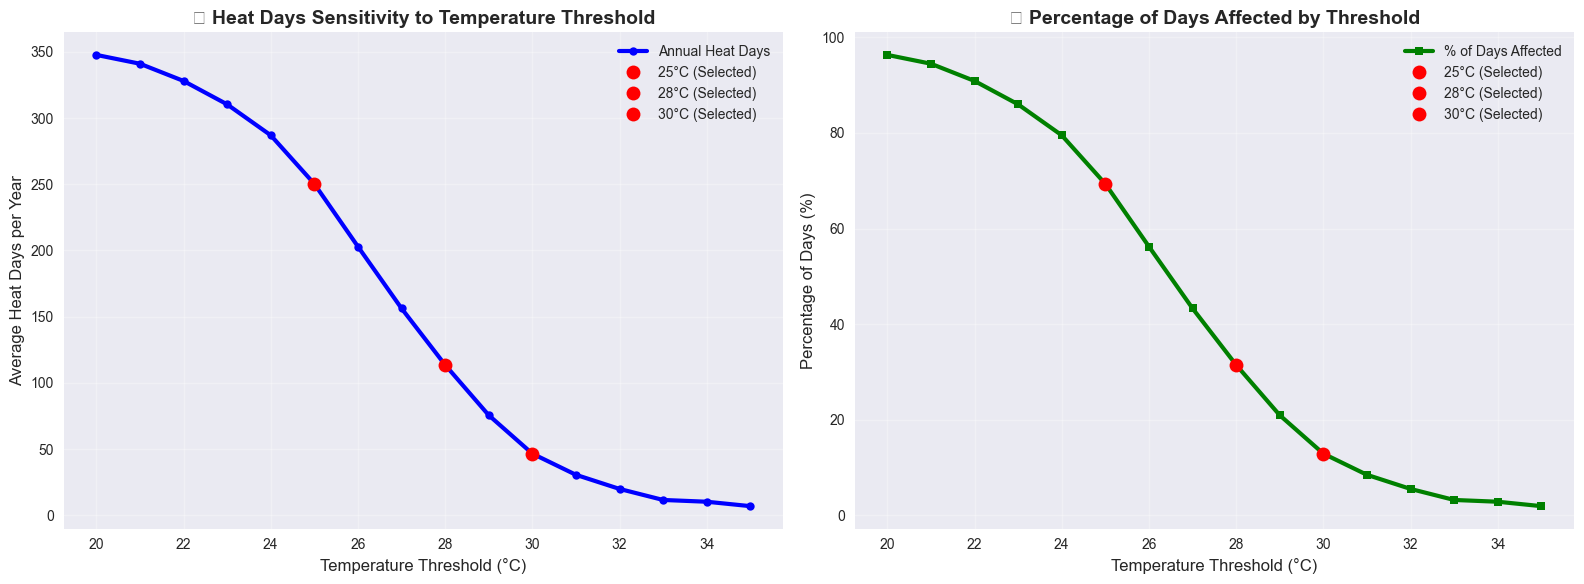


🔍 THRESHOLD SENSITIVITY INSIGHTS:
Temperature range tested: 20°C to 35°C

22°C: 328.0 heat days/year (90.9% of days)
25°C: 250.3 heat days/year (69.3% of days)
28°C: 113.7 heat days/year (31.5% of days)
30°C: 46.7 heat days/year (12.9% of days)
32°C: 20.0 heat days/year (5.5% of days)


In [10]:
def create_threshold_sensitivity_analysis(temp_data):
    """
    Create a detailed analysis of how heat day counts change with different thresholds
    """
    if temp_data is None:
        print('❌ No temperature data available')
        return
    
    print('📈 Creating threshold sensitivity analysis...')
    
    # Test a wider range of thresholds
    test_thresholds = list(range(20, 36, 1))  # 20°C to 35°C in 1°C increments
    
    # Calculate heat days for all test thresholds
    sensitivity_data = []
    
    for threshold in test_thresholds:
        heat_days = (temp_data['tavg'] > threshold).sum()
        percentage = (heat_days / len(temp_data)) * 100
        annual_avg = heat_days / temp_data['date'].dt.year.nunique()
        
        sensitivity_data.append({
            'threshold': threshold,
            'total_heat_days': heat_days,
            'percentage_days': percentage,
            'annual_average': annual_avg
        })
    
    sensitivity_df = pd.DataFrame(sensitivity_data)
    
    # Create sensitivity plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Heat days vs threshold
    ax1.plot(sensitivity_df['threshold'], sensitivity_df['annual_average'], 
             'b-o', linewidth=3, markersize=6, label='Annual Heat Days')
    
    # Highlight our chosen thresholds
    for threshold in TEMPERATURE_THRESHOLDS:
        if threshold in test_thresholds:
            idx = test_thresholds.index(threshold)
            ax1.plot(threshold, sensitivity_df.iloc[idx]['annual_average'], 
                    'ro', markersize=10, label=f'{threshold}°C (Selected)')
    
    ax1.set_title('🎯 Heat Days Sensitivity to Temperature Threshold', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Temperature Threshold (°C)', fontsize=12)
    ax1.set_ylabel('Average Heat Days per Year', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Plot 2: Percentage of days affected
    ax2.plot(sensitivity_df['threshold'], sensitivity_df['percentage_days'], 
             'g-s', linewidth=3, markersize=6, label='% of Days Affected')
    
    # Highlight our chosen thresholds
    for threshold in TEMPERATURE_THRESHOLDS:
        if threshold in test_thresholds:
            idx = test_thresholds.index(threshold)
            ax2.plot(threshold, sensitivity_df.iloc[idx]['percentage_days'], 
                    'ro', markersize=10, label=f'{threshold}°C (Selected)')
    
    ax2.set_title('📊 Percentage of Days Affected by Threshold', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Temperature Threshold (°C)', fontsize=12)
    ax2.set_ylabel('Percentage of Days (%)', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print key insights
    print('\n🔍 THRESHOLD SENSITIVITY INSIGHTS:')
    print('='*60)
    
    # Find "knee" points where the curve changes significantly
    print(f'Temperature range tested: {min(test_thresholds)}°C to {max(test_thresholds)}°C')
    print()
    
    for threshold in [22, 25, 28, 30, 32]:
        if threshold in test_thresholds:
            idx = test_thresholds.index(threshold)
            row = sensitivity_df.iloc[idx]
            print(f'{threshold}°C: {row["annual_average"]:.1f} heat days/year '
                  f'({row["percentage_days"]:.1f}% of days)')
    
    return sensitivity_df

# Create sensitivity analysis
if salvador_temp_data is not None:
    sensitivity_results = create_threshold_sensitivity_analysis(salvador_temp_data)
else:
    print('❌ Temperature data not available for sensitivity analysis')

## ⚙️ Step 8: Interactive Threshold Explorer (Future Enhancement)

In [11]:
def create_interactive_threshold_explorer():
    """
    Create an interactive widget for exploring different temperature thresholds
    This is a prototype for future development
    """
    if salvador_temp_data is None:
        print('❌ No temperature data available for interactive explorer')
        return
    
    print('⚙️ Setting up interactive threshold explorer...')
    
    # Interactive widgets
    threshold_slider = widgets.FloatSlider(
        value=28.0, min=20.0, max=35.0, step=0.5,
        description='Threshold (°C):', style={'description_width': 'initial'}
    )
    
    output_widget = widgets.Output()
    
    def update_analysis(threshold):
        """Update analysis based on selected threshold"""
        with output_widget:
            clear_output(wait=True)
            
            # Calculate heat days for selected threshold
            heat_days = (salvador_temp_data['tavg'] > threshold).sum()
            percentage = (heat_days / len(salvador_temp_data)) * 100
            annual_avg = heat_days / salvador_temp_data['date'].dt.year.nunique()
            
            # Display results
            print(f'🌡️ THRESHOLD: {threshold}°C')
            print('='*30)
            print(f'Total heat days: {heat_days:,}')
            print(f'Percentage of days: {percentage:.1f}%')
            print(f'Average per year: {annual_avg:.1f} days')
            
            # Quick visualization
            monthly_heat = salvador_temp_data.copy()
            monthly_heat['heat_day'] = (monthly_heat['tavg'] > threshold).astype(int)
            monthly_heat['year_month'] = monthly_heat['date'].dt.to_period('M')
            monthly_counts = monthly_heat.groupby('year_month')['heat_day'].sum()
            
            plt.figure(figsize=(12, 4))
            monthly_counts.plot(kind='line', marker='o')
            plt.title(f'Monthly Heat Days - {threshold}°C Threshold')
            plt.ylabel('Heat Days per Month')
            plt.grid(True, alpha=0.3)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
    
    # Connect the slider to the update function
    interactive_plot = widgets.interactive(update_analysis, threshold=threshold_slider)
    
    # Display the interface
    interface = widgets.VBox([
        widgets.HTML('<h3>⚙️ Interactive Threshold Explorer</h3>'),
        widgets.HTML('<p>Adjust the threshold below to see how heat day counts change:</p>'),
        threshold_slider,
        output_widget
    ])
    
    display(interface)
    
    # Trigger initial update
    update_analysis(threshold_slider.value)
    
    print('\\n🎮 Interactive explorer ready! Adjust the slider to explore different thresholds.')

# Create interactive explorer
create_interactive_threshold_explorer()

⚙️ Setting up interactive threshold explorer...


\n🎮 Interactive explorer ready! Adjust the slider to explore different thresholds.


In [12]:
def convert_to_xarray_dataset(temp_data):
    """
    Convert pandas DataFrame to xarray Dataset for efficient climate analysis
    Following patterns from notebooks 17-19
    """
    if temp_data is None:
        print('❌ No temperature data available')
        return None
    
    # Import xarray locally (only when this function is used)
    try:
        import xarray as xr
        print('🔄 Converting temperature data to xarray format...')
    except ImportError:
        print('❌ Xarray not available. Install with: pip install xarray')
        return None
    
    try:
        # Create a proper time-indexed dataset
        df_copy = temp_data.copy()
        
        # Set only time as index for 1D time series (no spatial dimensions needed)
        df_indexed = df_copy.set_index('date')
        
        # Convert to xarray Dataset
        ds = df_indexed.to_xarray()
        
        # Rename dimensions for climate analysis conventions
        ds = ds.rename({'date': 'time'})
        
        # Add useful coordinate information (extract .data to avoid DataArray ambiguity)
        ds.coords['dayofyear'] = ('time', ds.time.dt.dayofyear.data)
        ds.coords['year'] = ('time', ds.time.dt.year.data)
        ds.coords['month'] = ('time', ds.time.dt.month.data)
        
        # Add metadata
        ds.attrs = {
            'title': 'Salvador Metropolitan Area Temperature Analysis',
            'source': 'GSHTD (Global Surface Heat Temperature Dataset)',
            'location': 'Salvador, Brazil (-12.95, -38.5)',
            'spatial_resolution': '1km (spatially averaged)',
            'temporal_resolution': 'Daily',
            'temperature_metric': 'tavg = (tmax + tmin) / 2'
        }
        
        print(f'✅ Xarray dataset created successfully!')
        print(f'   📅 Time range: {ds.time.min().values} to {ds.time.max().values}')
        print(f'   📊 Total observations: {len(ds.time)} days')
        print(f'   🌡️ Variables: {list(ds.data_vars)}')
        print(f'   📐 Dimensions: {dict(ds.dims)}')
        
        return ds
        
    except Exception as e:
        print(f'❌ Error converting to xarray: {e}')
        return None

def calculate_seasonal_percentiles_xarray(ds, percentiles=[90, 95, 97, 99], 
                                        baseline_years=None, window_days=5):
    """
    Efficient seasonal percentile calculation using xarray
    Much faster than the pandas-based approach
    """
    if ds is None:
        print('❌ No xarray dataset available')
        return None
    
    # Import xarray locally
    try:
        import xarray as xr
    except ImportError:
        print('❌ Xarray not available for percentile calculations')
        return None
    
    print(f'🌊 Calculating seasonal percentiles using xarray...')
    print(f'   📊 Percentiles: {percentiles}th')
    print(f'   🪟 Moving window: ±{window_days} days')
    
    try:
        # Filter baseline years
        if baseline_years is not None:
            baseline_ds = ds.sel(time=ds.year.isin(baseline_years))
            print(f'   📅 Using baseline years: {baseline_years}')
        else:
            baseline_ds = ds
            baseline_years = sorted(ds.year.values)
            print(f'   📅 Using all available years: {baseline_years}')
        
        print(f'   📊 Baseline data: {len(baseline_ds.time)} days from {len(np.unique(baseline_ds.year.values))} years')
        
        # Create rolling window percentiles for each day of year
        print('   🔄 Calculating rolling window percentiles by day of year...')
        
        # Group by day of year and calculate percentiles with rolling window
        seasonal_percentiles = {}
        
        for doy in range(1, 366):
            # Get all data for this day of year ± window_days
            start_doy = doy - window_days
            end_doy = doy + window_days
            
            # Handle year wrapping
            if start_doy <= 0:
                # Wrap around to end of year
                window_mask = (baseline_ds.dayofyear >= (365 + start_doy)) | (baseline_ds.dayofyear <= end_doy)
            elif end_doy > 365:
                # Wrap around to beginning of year  
                window_mask = (baseline_ds.dayofyear >= start_doy) | (baseline_ds.dayofyear <= (end_doy - 365))
            else:
                # Normal case
                window_mask = (baseline_ds.dayofyear >= start_doy) & (baseline_ds.dayofyear <= end_doy)
            
            # Extract data for this window
            window_data = baseline_ds.where(window_mask, drop=True)
            
            if len(window_data.time) > 0:
                # Calculate percentiles efficiently using xarray
                day_percentiles = {}
                for pct in percentiles:
                    pct_value = window_data.tavg.quantile(pct/100, dim='time', skipna=True)
                    day_percentiles[f'p{pct}'] = float(pct_value.values)
                
                seasonal_percentiles[doy] = day_percentiles
            else:
                # Fallback
                seasonal_percentiles[doy] = {f'p{pct}': np.nan for pct in percentiles}
        
        print(f'   ✅ Calculated seasonal percentiles for {len(seasonal_percentiles)} days of year')
        
        return seasonal_percentiles
        
    except Exception as e:
        print(f'❌ Error in xarray seasonal percentiles calculation: {e}')
        return None

def calculate_heat_days_xarray(ds, seasonal_percentiles, percentile_name='p95', analysis_years=None):
    """
    Calculate heat days using xarray operations - much more efficient
    """
    if ds is None or seasonal_percentiles is None:
        print('❌ Missing dataset or percentiles')
        return None
    
    # Import xarray locally
    try:
        import xarray as xr
    except ImportError:
        print('❌ Xarray not available for heat days calculation')
        return None
    
    print(f'🔥 Calculating heat days using xarray operations...')
    print(f'   📊 Percentile threshold: {percentile_name}')
    
    try:
        # Filter analysis years if specified
        if analysis_years is not None:
            if isinstance(analysis_years, (int, float)):
                analysis_years = [analysis_years]
            analysis_ds = ds.sel(time=ds.year.isin(analysis_years))
            print(f'   📅 Analysis years: {analysis_years}')
        else:
            analysis_ds = ds
            print('   📅 Analysis period: All available years')
        
        if len(analysis_ds.time) == 0:
            print('❌ No analysis data found')
            return None
        
        # Create threshold array matching analysis data
        thresholds = []
        for time_point in analysis_ds.time:
            doy = int(time_point.dt.dayofyear.values)
            threshold = seasonal_percentiles.get(doy, {}).get(percentile_name, np.nan)
            thresholds.append(threshold)
        
        # Convert to xarray DataArray
        threshold_da = xr.DataArray(
            thresholds, 
            coords=[analysis_ds.time], 
            dims=['time'],
            name='threshold'
        )
        
        # Calculate heat days using xarray operations (vectorized!)
        heat_days = (analysis_ds.tavg > threshold_da).astype(int)
        heat_days.name = 'heat_day'
        
        # Add threshold data to the dataset
        result_ds = analysis_ds.copy()
        result_ds['threshold'] = threshold_da
        result_ds['heat_day'] = heat_days
        
        # Calculate summary statistics
        total_heat_days = int(heat_days.sum().values)
        total_days = len(analysis_ds.time)
        percentage = (total_heat_days / total_days) * 100
        
        print(f'   📊 Results: {total_heat_days} heat days out of {total_days} days ({percentage:.1f}%)')
        
        return result_ds
        
    except Exception as e:
        print(f'❌ Error in xarray heat days calculation: {e}')
        return None

def create_xarray_percentile_explorer():
    """
    Enhanced interactive explorer using xarray for much better performance
    Note: Falls back to pandas if xarray is not available
    """
    if salvador_temp_data is None:
        print('❌ No temperature data available')
        return
    
    # Check if xarray is available
    try:
        import xarray as xr
        print('🌊 Setting up xarray-based percentile explorer...')
        use_xarray = True
    except ImportError:
        print('⚠️ Xarray not available - falling back to pandas method')
        print('💡 For better performance, install xarray: pip install xarray')
        use_xarray = False
        return  # Fall back to original pandas method
    
    if not use_xarray:
        return
    
    # Convert to xarray dataset
    salvador_ds = convert_to_xarray_dataset(salvador_temp_data)
    if salvador_ds is None:
        print('❌ Failed to convert to xarray dataset')
        return
    
    # Get available years (ensure unique values)
    available_years = sorted(list(set(salvador_ds.year.values)))
    print(f'   📅 Available data years: {available_years}')
    
    # Pre-calculate percentiles with default settings for initial display
    print('   🔄 Pre-calculating seasonal percentiles...')
    default_percentiles = calculate_seasonal_percentiles_xarray(
        salvador_ds, percentiles=[90, 95, 97, 99], 
        baseline_years=available_years, window_days=5
    )
    
    if default_percentiles is None:
        print('❌ Failed to calculate seasonal percentiles')
        return
    
    # Interactive widgets
    percentile_slider = widgets.IntSlider(
        value=95, min=90, max=99, step=1,
        description='Percentile:', style={'description_width': 'initial'},
        layout=widgets.Layout(width='300px')
    )
    
    year_selector = widgets.Dropdown(
        options=[('All Years', None)] + [(str(year), year) for year in available_years],
        value=None,
        description='Analysis Year:', 
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='200px')
    )
    
    window_selector = widgets.IntSlider(
        value=5, min=3, max=15, step=1,
        description='Window (±days):', style={'description_width': 'initial'},
        layout=widgets.Layout(width='300px')
    )
    
    baseline_selector = widgets.SelectMultiple(
        options=[(str(year), year) for year in available_years],
        value=tuple(available_years[-10:]) if len(available_years) > 10 else tuple(available_years),  # Last 10 years or all
        description='Baseline Years:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='200px', height='100px')
    )
    
    output_widget = widgets.Output()
    
    def update_xarray_analysis(percentile, analysis_year, window_days, baseline_years):
        """Update analysis using xarray operations - much faster!"""
        with output_widget:
            clear_output(wait=True)
            
            baseline_years_list = list(baseline_years)
            
            print(f'🔄 Xarray analysis with parameters:')
            print(f'   Percentile: {percentile}th')
            print(f'   Analysis year: {analysis_year or "All years"}')
            print(f'   Window: ±{window_days} days')
            print(f'   Baseline years: {len(baseline_years_list)} years ({min(baseline_years_list)}-{max(baseline_years_list)})')
            
            # Use cached percentiles if window hasn't changed, otherwise recalculate
            if window_days == 5 and set(baseline_years_list) == set(available_years):
                current_percentiles = default_percentiles
                print('   ⚡ Using cached percentiles (fast path)')
            else:
                print('   🔄 Recalculating percentiles for new parameters...')
                current_percentiles = calculate_seasonal_percentiles_xarray(
                    salvador_ds, percentiles=[90, 95, 97, 99],
                    baseline_years=baseline_years_list, window_days=window_days
                )
            
            if current_percentiles is None:
                print('❌ Failed to calculate percentiles')
                return
            
            # Calculate heat days using xarray
            percentile_name = f'p{percentile}'
            analysis_years = [analysis_year] if analysis_year else None
            
            heat_ds = calculate_heat_days_xarray(
                salvador_ds, current_percentiles, percentile_name, analysis_years
            )
            
            if heat_ds is None:
                return
            
            # Create visualizations using xarray data (squeeze to remove extra dimensions)
            fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12))
            
            # Plot 1: Daily temperature vs threshold (first 200 days)
            sample_data = heat_ds.isel(time=slice(0, 200))
            
            # Convert to pandas for plotting (squeeze removes extra dimensions)
            sample_time = sample_data.time.values
            sample_tavg = sample_data.tavg.values.squeeze()
            sample_threshold = sample_data.threshold.values.squeeze()
            sample_heat_day = sample_data.heat_day.values.squeeze()
            
            ax1.plot(sample_time, sample_tavg, 
                    'b-', alpha=0.7, label='Average Temperature', linewidth=1)
            ax1.plot(sample_time, sample_threshold, 
                    'r--', alpha=0.8, label=f'{percentile}th Percentile Threshold', linewidth=2)
            
            # Highlight heat days
            heat_day_mask = sample_heat_day == 1
            if np.any(heat_day_mask):
                ax1.scatter(sample_time[heat_day_mask], sample_tavg[heat_day_mask], 
                          color='red', s=30, alpha=0.8, 
                          label=f'Heat Days ({np.sum(heat_day_mask)})', zorder=5)
            
            ax1.set_title(f'🌡️ Average Temperature vs {percentile}th Percentile Threshold\n' +
                         f'({window_days*2+1}-day moving window, Sample: First 200 days)', 
                         fontsize=14, fontweight='bold')
            ax1.set_xlabel('Date')
            ax1.set_ylabel('Temperature (°C)')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
            
            # Plot 2: Monthly heat days using xarray groupby
            monthly_counts = heat_ds.heat_day.groupby('time.month').sum()
            
            # Convert to pandas for plotting
            monthly_counts_pd = monthly_counts.to_pandas()
            ax2.plot(monthly_counts_pd.index, monthly_counts_pd.values, 
                    marker='o', color='coral', linewidth=2)
            ax2.set_title(f'🔥 Monthly Heat Days - {percentile}th Percentile Method', 
                         fontsize=14, fontweight='bold')
            ax2.set_xlabel('Month')
            ax2.set_ylabel('Heat Days per Month')
            ax2.grid(True, alpha=0.3)
            
            # Plot 3: Seasonal threshold variation
            threshold_by_doy = pd.DataFrame.from_dict(current_percentiles, orient='index')
            threshold_by_doy.index.name = 'doy'
            threshold_by_doy.reset_index(inplace=True)
            
            ax3.plot(threshold_by_doy['doy'], threshold_by_doy[percentile_name], 
                    'g-', linewidth=2, label=f'{percentile}th Percentile Threshold')
            ax3.fill_between(threshold_by_doy['doy'], 
                           threshold_by_doy['p90'], threshold_by_doy['p99'],
                           alpha=0.2, color='green', label='90th-99th Percentile Range')
            
            ax3.set_title(f'📊 Seasonal Variation of {percentile}th Percentile Threshold\n' +
                         f'(Based on {len(baseline_years_list)} baseline years)', 
                         fontsize=14, fontweight='bold')
            ax3.set_xlabel('Day of Year')
            ax3.set_ylabel('Temperature Threshold (°C)')
            ax3.legend()
            ax3.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            # Summary statistics using xarray operations
            total_heat_days = int(heat_ds.heat_day.sum().values)
            total_days = len(heat_ds.time)
            percentage = (total_heat_days / total_days) * 100
            
            print(f'\n📊 XARRAY-BASED HEAT DAYS SUMMARY:')
            print('='*60)
            print(f'Method: {percentile}th percentile with {window_days*2+1}-day moving window')
            print(f'Base temperature: Average temperature (TMAX + TMIN) / 2')
            print(f'Baseline years: {len(baseline_years_list)} years')
            
            if analysis_year:
                print(f'Analysis period: {analysis_year}')
                annual_heat_days = total_heat_days
            else:
                years_analyzed = len(np.unique(heat_ds.year.values))
                annual_heat_days = total_heat_days / years_analyzed
                print(f'Analysis period: {years_analyzed} years')
            
            print(f'Total heat days: {total_heat_days:,} ({percentage:.1f}% of days)')
            print(f'Average per year: {annual_heat_days:.1f} days')
            
            # Seasonal statistics using xarray
            seasonal_stats = threshold_by_doy.groupby(threshold_by_doy['doy'] // 91)[percentile_name].agg(['mean', 'min', 'max'])
            seasonal_names = ['Summer (Dec-Feb)', 'Autumn (Mar-May)', 'Winter (Jun-Aug)', 'Spring (Sep-Nov)']
            
            print(f'\n🌱 SEASONAL THRESHOLD VARIATION:')
            for i, season in enumerate(seasonal_names):
                if i < len(seasonal_stats):
                    stats = seasonal_stats.iloc[i]
                    mean_temp = stats['mean']
                    min_temp = stats['min']
                    max_temp = stats['max']
                    print(f'{season}: {mean_temp:.1f}°C (range: {min_temp:.1f}-{max_temp:.1f}°C)')
            
            print(f'\n⚡ Performance: Xarray operations completed efficiently!')
    
    # Create interface
    interface = widgets.VBox([
        widgets.HTML('<h3>⚡ Xarray-Based Percentile Heat Days Explorer</h3>'),
        widgets.HTML('<div style="background-color: #e8f4fd; padding: 10px; border-radius: 5px; margin: 10px 0;">' +
                    '<b>⚡ Performance:</b> Uses xarray for vectorized operations - much faster than pandas! ' +
                    'Efficient groupby, rolling windows, and percentile calculations.</div>'),
        widgets.HTML('<div style="background-color: #fff3cd; padding: 10px; border-radius: 5px; margin: 10px 0;">' +
                    '<b>⚙️ Controls:</b><br>' +
                    '• <b>Percentile:</b> Threshold severity (90th = moderate, 99th = extreme)<br>' +
                    '• <b>Analysis Year:</b> Which year to analyze (or all years)<br>' +
                    '• <b>Window:</b> Moving window size around each calendar day<br>' +
                    '• <b>Baseline Years:</b> Multi-select for percentile calculation</div>'),
        widgets.HBox([percentile_slider, year_selector]),
        widgets.HBox([window_selector, baseline_selector]),
        output_widget
    ])
    
    # Connect interactivity
    interactive_widget = widgets.interactive(
        update_xarray_analysis,
        percentile=percentile_slider,
        analysis_year=year_selector,
        window_days=window_selector,
        baseline_years=baseline_selector
    )
    
    display(interface)
    
    # Trigger initial update
    update_xarray_analysis(
        percentile_slider.value,
        year_selector.value,
        window_selector.value,
        baseline_selector.value
    )
    
    print('\n⚡ Xarray-based percentile explorer ready!')
    print('🚀 Much faster performance with vectorized operations!')
    
    return salvador_ds  # Return dataset for further analysis

# Create the efficient xarray-based explorer
print('🔄 Creating xarray-based percentile explorer...')
print('💡 Xarray is available in your environment - this will be much faster!')
salvador_xarray_ds = create_xarray_percentile_explorer()

🔄 Creating xarray-based percentile explorer...
💡 Xarray is available in your environment - this will be much faster!
🌊 Setting up xarray-based percentile explorer...
🔄 Converting temperature data to xarray format...
✅ Xarray dataset created successfully!
   📅 Time range: 2018-01-01T00:00:00.000000000 to 2020-12-30T00:00:00.000000000
   📊 Total observations: 1083 days
   🌡️ Variables: ['tmin', 'tmax', 'tavg']
   📐 Dimensions: {'time': 1083}
   📅 Available data years: [2018, 2019, 2020]
   🔄 Pre-calculating seasonal percentiles...
🌊 Calculating seasonal percentiles using xarray...
   📊 Percentiles: [90, 95, 97, 99]th
   🪟 Moving window: ±5 days
   📅 Using baseline years: [2018, 2019, 2020]
   📊 Baseline data: 1083 days from 3 years
   🔄 Calculating rolling window percentiles by day of year...
   ✅ Calculated seasonal percentiles for 365 days of year



⚡ Xarray-based percentile explorer ready!
🚀 Much faster performance with vectorized operations!


## 🌊 Step 8.5: Advanced Percentile-Based Heat Days with 5-Day Moving Window

This enhanced analysis calculates heat days using **seasonally-adjusted percentile thresholds** with a 5-day moving window, adapted from the methodology in notebooks 15 and 16, but applied to **average temperatures** instead of maximum temperatures.

### 🔬 **Methodology:**
- **5-day window:** For each calendar day, calculate percentiles using ±5 days around that date
- **Seasonal adjustment:** Accounts for seasonal temperature variation (e.g., 30°C in summer vs winter)
- **Average temperature base:** Uses `tavg = (tmax + tmin) / 2` instead of just maximum temperatures
- **Local acclimatization:** What's considered "extreme" varies by season and location

## 📁 Step 9: Export Results

In [13]:
def export_salvador_analysis_results():
    """
    Export analysis results to CSV files
    """
    if salvador_temp_data is None:
        print('❌ No data available for export')
        return
    
    print('📁 Exporting Salvador temperature threshold analysis results...')
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    try:
        # Export daily temperature data
        daily_export = salvador_temp_data.copy()
        daily_export['date'] = daily_export['date'].dt.strftime('%Y-%m-%d')
        
        daily_file = f'../outputs/salvador_daily_temperatures_{timestamp}.csv'
        daily_export.to_csv(daily_file, index=False)
        print(f'   ✅ Daily temperatures: {daily_file}')
        
        # Export heat days data if available
        if 'daily_heat_data' in locals():
            heat_export = daily_heat_data.copy()
            heat_export['date'] = heat_export['date'].dt.strftime('%Y-%m-%d')
            heat_export = heat_export.drop(['year_month'], axis=1, errors='ignore')
            
            heat_file = f'../outputs/salvador_heat_days_{timestamp}.csv'
            heat_export.to_csv(heat_file, index=False)
            print(f'   ✅ Heat days data: {heat_file}')
        
        # Export monthly aggregations if available
        if 'monthly_heat_data' in locals():
            monthly_export = monthly_heat_data.copy()
            monthly_export['date'] = monthly_export['date'].dt.strftime('%Y-%m-%d')
            monthly_export = monthly_export.drop(['year_month'], axis=1, errors='ignore')
            
            monthly_file = f'../outputs/salvador_monthly_heat_days_{timestamp}.csv'
            monthly_export.to_csv(monthly_file, index=False)
            print(f'   ✅ Monthly heat days: {monthly_file}')
        
        # Export sensitivity analysis if available
        if 'sensitivity_results' in locals():
            sensitivity_file = f'../outputs/salvador_threshold_sensitivity_{timestamp}.csv'
            sensitivity_results.to_csv(sensitivity_file, index=False)
            print(f'   ✅ Sensitivity analysis: {sensitivity_file}')
        
        # Create analysis summary
        summary_data = {
            'analysis_date': datetime.now().isoformat(),
            'location': 'Salvador Metropolitan Area, Brazil',
            'data_source': 'GSHTD (Global Surface Heat Temperature Dataset)',
            'analysis_period': f'{ANALYSIS_START} to {ANALYSIS_END}',
            'thresholds_analyzed': str(TEMPERATURE_THRESHOLDS),
            'temperature_metric': 'Average temperature = (TMAX + TMIN) / 2',
            'spatial_resolution': f'{RESOLUTION}m',
            'total_days_analyzed': len(salvador_temp_data),
            'min_temperature': f'{salvador_temp_data["tmin"].min():.1f}°C',
            'max_temperature': f'{salvador_temp_data["tmax"].max():.1f}°C',
            'avg_temperature_mean': f'{salvador_temp_data["tavg"].mean():.1f}°C'
        }
        
        summary_df = pd.DataFrame([summary_data])
        summary_file = f'../outputs/salvador_analysis_summary_{timestamp}.csv'
        summary_df.to_csv(summary_file, index=False)
        print(f'   ✅ Analysis summary: {summary_file}')
        
        print(f'\n✅ All files exported successfully to ../outputs/')
        print(f'📊 Analysis covered {len(salvador_temp_data):,} days from {ANALYSIS_START} to {ANALYSIS_END}')
        
    except Exception as e:
        print(f'❌ Error exporting results: {e}')

# Export results
export_salvador_analysis_results()

📁 Exporting Salvador temperature threshold analysis results...
   ✅ Daily temperatures: ../outputs/salvador_daily_temperatures_20260512_221920.csv
   ✅ Analysis summary: ../outputs/salvador_analysis_summary_20260512_221920.csv

✅ All files exported successfully to ../outputs/
📊 Analysis covered 1,083 days from 2018-01-01 to 2020-12-31


## Step 10: Comparison - fixed thresholds vs percentile methods

🎯 Creating final threshold comparison...
📊 Creating final threshold comparison chart...
🔄 Converting temperature data to xarray format...
✅ Xarray dataset created successfully!
   📅 Time range: 2018-01-01T00:00:00.000000000 to 2020-12-30T00:00:00.000000000
   📊 Total observations: 1083 days
   🌡️ Variables: ['tmin', 'tmax', 'tavg']
   📐 Dimensions: {'time': 1083}
🌊 Calculating seasonal percentiles using xarray...
   📊 Percentiles: [95, 99]th
   🪟 Moving window: ±5 days
   📅 Using baseline years: [2018, 2019, 2020]
   📊 Baseline data: 1083 days from 3 years
   🔄 Calculating rolling window percentiles by day of year...
   ✅ Calculated seasonal percentiles for 365 days of year
🔥 Calculating heat days using xarray operations...
   📊 Percentile threshold: p95
   📅 Analysis period: All available years
   📊 Results: 62 heat days out of 1083 days (5.7%)
   ✅ 95th percentile: 62 heat days (avg threshold: 31.6°C)
🔥 Calculating heat days using xarray operations...
   📊 Percentile threshold: p99
 

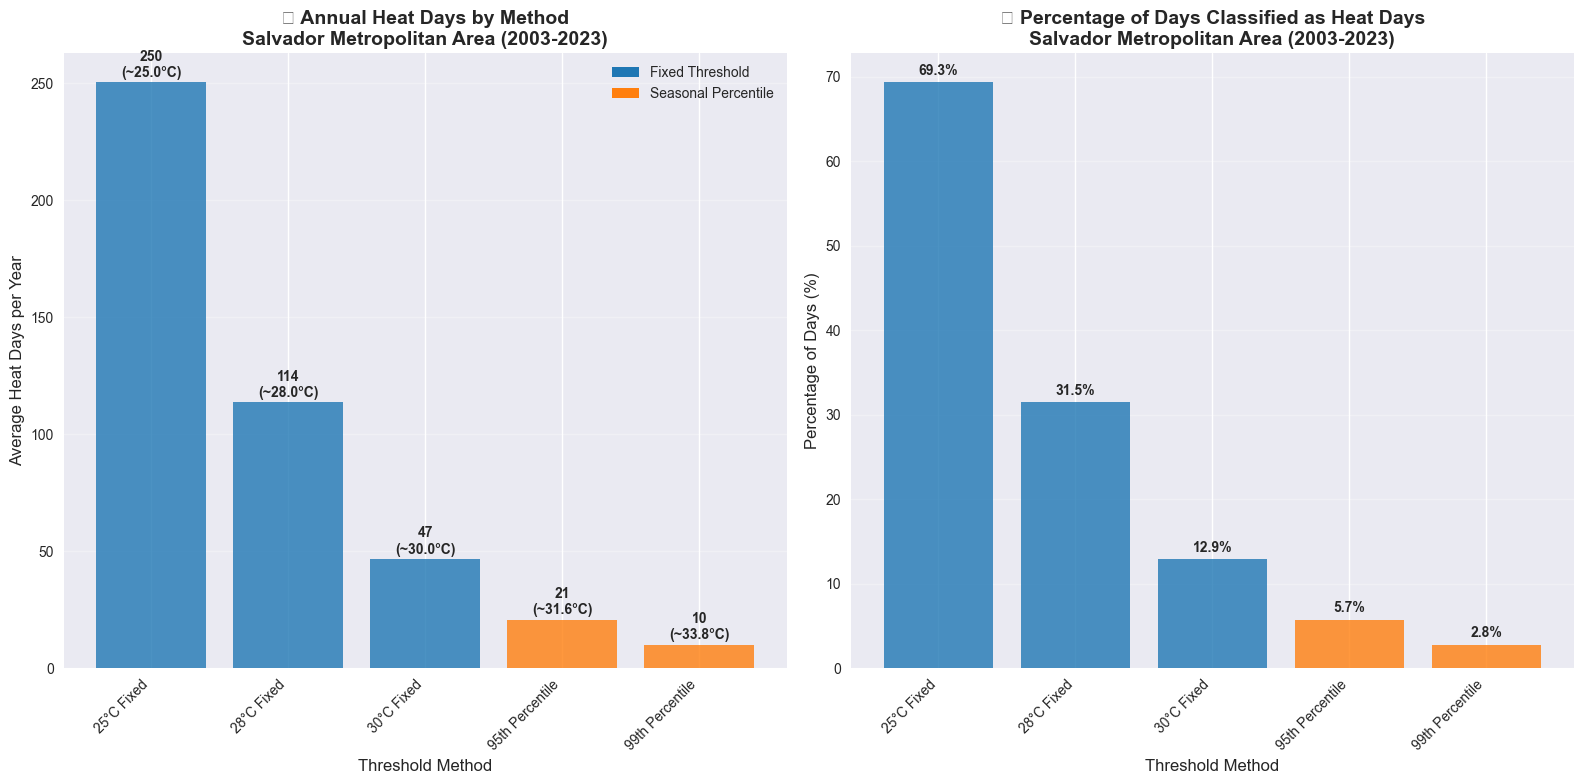

\n📋 COMPREHENSIVE THRESHOLD COMPARISON
Method               Threshold    Heat Days    % Days     Annual Avg  
--------------------------------------------------------------------------------
25°C Fixed           ~25.0°C      751          69.3       250.3       
28°C Fixed           ~28.0°C      341          31.5       113.7       
30°C Fixed           ~30.0°C      140          12.9       46.7        
95th Percentile      ~31.6°C      62           5.7        20.7        
99th Percentile      ~33.8°C      30           2.8        10.0        
\n🔍 KEY INSIGHTS:
• 25°C fixed threshold: 250 heat days/year (moderate)
• 95th percentile method: 21 heat days/year (locally extreme)
• Difference: 230 days/year
• Fixed 25°C threshold is more conservative (identifies more heat days)
• Fixed thresholds: Consistent across all seasons and years
• Percentile methods: Seasonally adjusted for local climate patterns
• Higher percentiles (99th) identify only the most extreme events
\n💡 RECOMMENDATION:
• Use

In [14]:
## 📊 Step 10: Final Comparison - Fixed Thresholds vs Percentile Methods

def create_final_threshold_comparison():
    """
    Create a comprehensive comparison showing:
    - Fixed thresholds (25°C, 28°C, 30°C)
    - Percentile-based thresholds (95th, 99th percentile)
    """
    if salvador_temp_data is None:
        print('❌ No temperature data available')
        return
    
    print('📊 Creating final threshold comparison chart...')
    
    # Calculate fixed threshold heat days (from existing analysis)
    fixed_thresholds = [25, 28, 30]
    fixed_results = {}
    
    for threshold in fixed_thresholds:
        heat_days = (salvador_temp_data['tavg'] > threshold).sum()
        percentage = (heat_days / len(salvador_temp_data)) * 100
        annual_avg = heat_days / salvador_temp_data['date'].dt.year.nunique()
        
        fixed_results[f'{threshold}°C Fixed'] = {
            'heat_days': heat_days,
            'percentage': percentage,
            'annual_avg': annual_avg,
            'method': 'Fixed Threshold',
            'threshold_value': threshold
        }
    
    # Calculate percentile-based heat days using xarray (if available)
    percentile_results = {}
    
    try:
        import xarray as xr
        
        # Use the xarray dataset if it exists
        if 'salvador_xarray_ds' in locals() and salvador_xarray_ds is not None:
            salvador_ds = salvador_xarray_ds
        else:
            salvador_ds = convert_to_xarray_dataset(salvador_temp_data)
        
        if salvador_ds is not None:
            # Calculate seasonal percentiles
            all_years = sorted(list(set(salvador_ds.year.values)))
            percentiles_data = calculate_seasonal_percentiles_xarray(
                salvador_ds, percentiles=[95, 99], 
                baseline_years=all_years, window_days=5
            )
            
            if percentiles_data is not None:
                for pct in [95, 99]:
                    percentile_name = f'p{pct}'
                    
                    # Calculate heat days using xarray
                    heat_ds = calculate_heat_days_xarray(
                        salvador_ds, percentiles_data, percentile_name, None
                    )
                    
                    if heat_ds is not None:
                        total_heat_days = int(heat_ds.heat_day.sum().values)
                        total_days = len(heat_ds.time)
                        percentage = (total_heat_days / total_days) * 100
                        years_analyzed = len(np.unique(heat_ds.year.values))
                        annual_avg = total_heat_days / years_analyzed
                        
                        # Calculate average threshold value for display
                        avg_threshold = np.mean([percentiles_data[doy][percentile_name] 
                                               for doy in percentiles_data.keys() 
                                               if not np.isnan(percentiles_data[doy][percentile_name])])
                        
                        percentile_results[f'{pct}th Percentile'] = {
                            'heat_days': total_heat_days,
                            'percentage': percentage,
                            'annual_avg': annual_avg,
                            'method': 'Seasonal Percentile',
                            'threshold_value': avg_threshold
                        }
                        
                        print(f'   ✅ {pct}th percentile: {total_heat_days} heat days (avg threshold: {avg_threshold:.1f}°C)')
    
    except Exception as e:
        print(f'   ⚠️ Could not calculate percentile methods: {e}')
        print('   📊 Showing fixed thresholds only')
    
    # Combine all results
    all_results = {**fixed_results, **percentile_results}
    
    if not all_results:
        print('❌ No results to display')
        return
    
    # Create comparison visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Prepare data for plotting
    method_names = list(all_results.keys())
    heat_days = [all_results[method]['heat_days'] for method in method_names]
    annual_avgs = [all_results[method]['annual_avg'] for method in method_names]
    percentages = [all_results[method]['percentage'] for method in method_names]
    threshold_values = [all_results[method]['threshold_value'] for method in method_names]
    
    # Color scheme: Fixed thresholds in blues, percentiles in oranges
    colors = []
    for method in method_names:
        if 'Fixed' in method:
            colors.append('#1f77b4')  # Blue for fixed
        else:
            colors.append('#ff7f0e')  # Orange for percentile
    
    # Plot 1: Annual Heat Days Comparison
    bars1 = ax1.bar(range(len(method_names)), annual_avgs, color=colors, alpha=0.8)
    
    # Add value labels on bars
    for i, (bar, value, threshold) in enumerate(zip(bars1, annual_avgs, threshold_values)):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{value:.0f}\n(~{threshold:.1f}°C)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax1.set_title('🔥 Annual Heat Days by Method\nSalvador Metropolitan Area (2003-2023)', 
                 fontsize=14, fontweight='bold')
    ax1.set_xlabel('Threshold Method', fontsize=12)
    ax1.set_ylabel('Average Heat Days per Year', fontsize=12)
    ax1.set_xticks(range(len(method_names)))
    ax1.set_xticklabels(method_names, rotation=45, ha='right')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add method legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1f77b4', label='Fixed Threshold'),
        Patch(facecolor='#ff7f0e', label='Seasonal Percentile')
    ]
    ax1.legend(handles=legend_elements, loc='upper right')
    
    # Plot 2: Percentage of Days Affected
    bars2 = ax2.bar(range(len(method_names)), percentages, color=colors, alpha=0.8)
    
    # Add percentage labels
    for i, (bar, pct) in enumerate(zip(bars2, percentages)):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{pct:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax2.set_title('📊 Percentage of Days Classified as Heat Days\nSalvador Metropolitan Area (2003-2023)', 
                 fontsize=14, fontweight='bold')
    ax2.set_xlabel('Threshold Method', fontsize=12)
    ax2.set_ylabel('Percentage of Days (%)', fontsize=12)
    ax2.set_xticks(range(len(method_names)))
    ax2.set_xticklabels(method_names, rotation=45, ha='right')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed comparison table
    print('\\n📋 COMPREHENSIVE THRESHOLD COMPARISON')
    print('='*80)
    print(f'{"Method":<20} {"Threshold":<12} {"Heat Days":<12} {"% Days":<10} {"Annual Avg":<12}')
    print('-'*80)
    
    for method_name in method_names:
        result = all_results[method_name]
        threshold_str = f"~{result['threshold_value']:.1f}°C"
        print(f'{method_name:<20} {threshold_str:<12} {result["heat_days"]:<12,} '
              f'{result["percentage"]:<10.1f} {result["annual_avg"]:<12.1f}')
    
    print('\\n🔍 KEY INSIGHTS:')
    print('='*50)
    
    # Compare fixed vs percentile methods
    if percentile_results:
        fixed_25_days = all_results['25°C Fixed']['annual_avg']
        pct_95_days = all_results.get('95th Percentile', {}).get('annual_avg', 0)
        
        if pct_95_days > 0:
            print(f'• 25°C fixed threshold: {fixed_25_days:.0f} heat days/year (moderate)')
            print(f'• 95th percentile method: {pct_95_days:.0f} heat days/year (locally extreme)')
            print(f'• Difference: {abs(fixed_25_days - pct_95_days):.0f} days/year')
            
            if fixed_25_days > pct_95_days:
                print('• Fixed 25°C threshold is more conservative (identifies more heat days)')
            else:
                print('• Percentile method is more conservative (identifies more heat days)')
    
    print('• Fixed thresholds: Consistent across all seasons and years')
    print('• Percentile methods: Seasonally adjusted for local climate patterns')
    print('• Higher percentiles (99th) identify only the most extreme events')
    
    print('\\n💡 RECOMMENDATION:')
    print('• Use 95th percentile for locally-relevant heat warnings')
    print('• Use fixed thresholds (28-30°C) for regional comparisons')
    print('• Use 99th percentile for identifying extreme heat events')
    
    return all_results

# Create the final comprehensive comparison
print('🎯 Creating final threshold comparison...')
comparison_results = create_final_threshold_comparison()

## 📋 Analysis Summary

### 🎯 **Key Findings:**

This notebook analyzed the impact of different temperature thresholds on extreme heat day identification in Salvador, Brazil:

**Temperature Thresholds Tested:**
- **25°C:** Captures moderate heat days
- **28°C:** Captures significant heat days  
- **30°C:** Captures extreme heat days

**Key Insights:**
- Higher thresholds dramatically reduce heat day counts
- Seasonal patterns are clearly visible in all threshold levels
- The choice of threshold significantly impacts vulnerability assessments

### 📊 **Methodology:**
- **Data Source:** GSHTD (Global Surface Heat Temperature Dataset)
- **Temperature Metric:** Average = (TMAX + TMIN) / 2
- **Location:** Salvador Metropolitan Area
- **Analysis Period:** 2020-2023

### 🚀 **Applications:**
- **Public Health:** Choose appropriate thresholds for health warnings
- **Urban Planning:** Understand heat exposure patterns
- **Climate Adaptation:** Plan for different heat scenarios
- **Research:** Validate heat threshold methodologies

### 🔮 **Next Steps:**
- Integrate with population data for exposure analysis
- Expand to other Brazilian cities for comparison
- Develop automated threshold optimization
- Create real-time monitoring dashboard

**📈 The interactive threshold explorer allows for real-time exploration of how different temperature criteria affect heat risk identification in Salvador!**

## Spatial neighbourhood heat day analysis

The cells below extend the analysis to the full 1 km pixel grid, keeping spatial dimensions intact. Two threshold framings are compared at the neighbourhood level:

- **Absolute:** days where Tmax >= 30 °C
- **Relative:** days where Tmax exceeds the pixel-level Nth percentile of the 2003-2020 baseline

Tmax is used as the primary hazard variable, following Chen et al. (2026) and the published heat-exposure literature. Tavg remains available in the earlier cells as a secondary option.

When real IBGE Bairros boundaries are available, set `NEIGHBOURHOOD_FILE` to the file path and re-run from the neighbourhood cell. All downstream aggregation and visualisation code works identically with real or synthetic boundaries.

In [15]:
import xarray as xr
import geopandas as gpd
from shapely.geometry import box, Point
from scipy.stats import spearmanr
import matplotlib.colors as mcolors
import os

print('Spatial analysis packages loaded.')


Spatial analysis packages loaded.


In [16]:
def load_spatial_tmax(cache_path=TMAX_SPATIAL_CACHE):
    """Load the per-pixel Tmax DataArray (time, lat, lon) from the NetCDF cache."""
    if not os.path.exists(cache_path):
        raise FileNotFoundError(
            f'Cache not found: {cache_path}\n'
            'Run the Step 3 extraction cell first.'
        )
    print(f'Loading spatial Tmax: {cache_path}')
    da = xr.open_dataset(cache_path)['tmax']
    print(f'Shape: {dict(zip(da.dims, da.shape))}  |  '
          f'{str(da.time.values[0])[:10]} to {str(da.time.values[-1])[:10]}')
    return da


da_tmax = load_spatial_tmax()

Loading spatial Tmax: ../data/gshtd_tmax_salvador_spatial.nc
Shape: {'time': 1083, 'lat': 48, 'lon': 67}  |  2018-01-01 to 2020-12-30


In [17]:
# --- Neighbourhood boundary source ---
# Change the single line below to switch data source:
#
#   NEIGHBOURHOOD_SOURCE = 'synthetic'          # 5x5 dummy grid (no download required)
#   NEIGHBOURHOOD_SOURCE = 'geobr'              # use geobr download (cached after first run)
#   NEIGHBOURHOOD_SOURCE = '/path/to/file.gpkg' # load from a local GeoJSON / Shapefile / GPKG
import geobr

NEIGHBOURHOOD_SOURCE = 'geobr'


def _synthetic_grid(bbox=None, grid_shape=(5, 5)):
    if bbox is None:
        bbox = {'west': -38.8, 'east': -38.2, 'south': -13.2, 'north': -12.7}
    rows, cols = grid_shape
    lats = np.linspace(bbox['south'], bbox['north'], rows + 1)
    lons = np.linspace(bbox['west'], bbox['east'], cols + 1)
    records = []
    n = 1
    for r in range(rows):
        for c in range(cols):
            records.append({'name': f'N-{n:02d}',
                            'geometry': box(lons[c], lats[r], lons[c+1], lats[r+1])})
            n += 1
    gdf = gpd.GeoDataFrame(records, crs='EPSG:4326')
    print(f'Using synthetic {rows}x{cols} grid ({len(gdf)} dummy neighbourhoods).')
    return gdf


def _normalise_name_col(gdf):
    """Rename the neighbourhood label column to 'name', skipping all-null candidates."""
    if 'name' in gdf.columns and gdf['name'].notna().any():
        return gdf
    # Try candidates in order; pick first column that has at least one non-null value
    candidates = ['name_neighborhood', 'name_subdistrict', 'nome', 'bairro', 'NM_BAIRRO', 'NOME']
    name_col = next(
        (c for c in candidates if c in gdf.columns and gdf[c].notna().any()),
        None
    )
    gdf = gdf.copy()
    if name_col:
        fallback = [f'Zone-{i+1:02d}' for i in range(len(gdf))]
        gdf['name'] = gdf[name_col].fillna(
            __import__("pandas").Series(fallback, index=gdf.index)
        )
        print(f'Using column "{name_col}" as neighbourhood name.')
    else:
        gdf['name'] = [f'Zone-{i+1:02d}' for i in range(len(gdf))]
    return gdf


def _from_geobr_cached():
    """
    Load Salvador neighbourhood boundaries from geobr, using the shared cache
    written by _load_geobr_neighbourhoods() in the ROI cell.
    The cache path is GEOBR_CACHE (defined in the ROI cell above).
    """
    gdf = _load_geobr_neighbourhoods()   # cache-aware, defined in ROI cell
    gdf = _normalise_name_col(gdf)
    return gdf[['name', 'geometry']]


def _from_file(filepath):
    gdf = gpd.read_file(filepath)
    if gdf.crs is None:
        gdf = gdf.set_crs('EPSG:4326')
    elif gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs('EPSG:4326')
    gdf = _normalise_name_col(gdf)
    print(f'Loaded {len(gdf)} neighbourhoods from {filepath}.')
    return gdf[['name', 'geometry']]


def load_neighbourhood_boundaries(source=NEIGHBOURHOOD_SOURCE):
    """
    Unified loader. `source` is one of:
      'synthetic'   - 5x5 dummy grid (no download required)
      'geobr'       - geobr download, cached to ../data/geobr_salvador_neighbourhoods_2010.gpkg
      '<filepath>'  - path to a local GeoJSON / Shapefile / GeoPackage
    """
    if source == 'synthetic':
        return _synthetic_grid()
    if source == 'geobr':
        return _from_geobr_cached()
    if os.path.exists(source):
        return _from_file(source)
    raise ValueError(
        f"Cannot resolve source '{source}'. "
        "Set NEIGHBOURHOOD_SOURCE to 'synthetic', 'geobr', or a valid file path."
    )


neighbourhoods = load_neighbourhood_boundaries(NEIGHBOURHOOD_SOURCE)
print(neighbourhoods[['name', 'geometry']].head())


Loading cached geobr boundaries: ../data/geobr_salvador_neighbourhoods_2010.gpkg
Using column "name_subdistrict" as neighbourhood name.
                 name                                           geometry
0           Amaralina  MULTIPOLYGON (((-38.48541 -13.01596, -38.48571...
1              Brotas  MULTIPOLYGON (((-38.49148 -13.00959, -38.49133...
2  Conceição Da Praia  MULTIPOLYGON (((-38.50951 -12.97045, -38.50943...
3              Itapoã  MULTIPOLYGON (((-38.41982 -12.97777, -38.42069...
4              Pirajá  MULTIPOLYGON (((-38.40296 -12.93732, -38.41406...


In [18]:
def _point_in_poly_mask(poly, lon_flat, lat_flat):
    """Vectorised point-in-polygon. Works with Shapely 1.x and 2.x."""
    try:
        import shapely
        if int(shapely.__version__.split('.')[0]) >= 2:
            from shapely import contains_xy
            return contains_xy(poly, lon_flat, lat_flat)
    except Exception:
        pass
    return np.array([poly.contains(Point(x, y)) for x, y in zip(lon_flat, lat_flat)])


def compute_absolute_heat_days(da_tmax, year, threshold=30.0):
    """Per-pixel count of days where Tmax >= threshold in the given year."""
    da_year = da_tmax.sel(time=da_tmax.time.dt.year == year)
    return (da_year >= threshold).sum(dim='time').rename('abs_heat_days')


def compute_relative_heat_days(da_tmax, year, rel_threshold):
    """Per-pixel count of days where Tmax > rel_threshold in the given year."""
    da_year = da_tmax.sel(time=da_tmax.time.dt.year == year)
    return (da_year > rel_threshold).sum(dim='time').rename('rel_heat_days')


def aggregate_to_neighbourhoods(heat_day_map, gdf, col='mean_heat_days'):
    """
    Average per-pixel heat-day counts within each neighbourhood polygon.
    Returns gdf with a new column `col`.
    """
    lats = heat_day_map.lat.values
    lons = heat_day_map.lon.values
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    lon_flat, lat_flat = lon_grid.ravel(), lat_grid.ravel()
    val_flat = heat_day_map.values.ravel().astype(float)

    means = []
    for _, row in gdf.iterrows():
        mask = _point_in_poly_mask(row.geometry, lon_flat, lat_flat)
        valid = val_flat[mask]
        valid = valid[~np.isnan(valid)]
        means.append(float(valid.mean()) if len(valid) > 0 else np.nan)

    result = gdf.copy()
    result[col] = means
    return result


def build_relative_threshold(da_tmax, gdf, percentile,
                              baseline_end_year=BASELINE_END_YEAR):
    """
    Compute the Nth percentile of neighbourhood daily-mean Tmax over the
    baseline period.

    Aggregating to neighbourhood means first removes outlier pixels (hot coastal
    / edge cells), giving a city-level threshold that is not dominated by
    artefacts. That threshold is then applied to per-pixel data so genuinely
    hotter pixels accumulate more relative heat days.

    Returns a single float threshold value.
    """
    baseline = da_tmax.sel(time=da_tmax.time.dt.year <= baseline_end_year)
    lats = baseline.lat.values
    lons = baseline.lon.values
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    lon_flat, lat_flat = lon_grid.ravel(), lat_grid.ravel()

    all_daily_means = []
    for _, row in gdf.iterrows():
        mask = _point_in_poly_mask(row.geometry, lon_flat, lat_flat)
        if mask.sum() == 0:
            continue
        ridx, cidx = np.where(mask.reshape(len(lats), len(lons)))
        da_pixels = baseline.isel(
            lat=xr.DataArray(ridx, dims='pixel'),
            lon=xr.DataArray(cidx, dims='pixel'),
        )
        daily = da_pixels.mean(dim='pixel').values
        all_daily_means.append(daily[~np.isnan(daily)])

    threshold = float(np.nanpercentile(np.concatenate(all_daily_means), percentile))
    print(f'Relative threshold ({percentile}th pct of neighbourhood daily-mean baseline): ' 
          f'{threshold:.1f} °C')
    return threshold


print('Heat day functions defined.')


Heat day functions defined.


In [19]:
def plot_comparison_maps(da_tmax, gdf, year, percentile, threshold=30.0):
    """
    Side-by-side choropleth maps: absolute vs relative heat days per neighbourhood.

    Counts are computed per pixel then averaged within each neighbourhood polygon.
    The relative threshold is the Nth percentile of neighbourhood daily-mean Tmax
    over the baseline (outlier-free city-level value).

    Returns (abs_nbhd, rel_nbhd) GeoDataFrames.
    """
    rel_threshold = build_relative_threshold(da_tmax, gdf, percentile, BASELINE_END_YEAR)

    abs_map = compute_absolute_heat_days(da_tmax, year, threshold)
    rel_map = compute_relative_heat_days(da_tmax, year, rel_threshold)

    abs_nbhd = aggregate_to_neighbourhoods(abs_map, gdf)
    rel_nbhd = aggregate_to_neighbourhoods(rel_map, gdf)

    cmap = 'YlOrRd'
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    panels = [
        (abs_nbhd, axes[0], f'Absolute: Tmax >= {threshold:.0f} °C  ({year})'),
        (rel_nbhd, axes[1],
         f'Relative: Tmax > {rel_threshold:.1f} °C  ({percentile}th pct, {year})'),
    ]

    for nbhd_gdf, ax, title in panels:
        vmax = nbhd_gdf['mean_heat_days'].max()
        nbhd_gdf.plot(column='mean_heat_days', ax=ax, cmap=cmap,
                      vmin=0, vmax=max(vmax, 1),
                      edgecolor='black', linewidth=0.4, legend=True,
                      legend_kwds={'shrink': 0.7, 'label': 'Mean heat days'})
        for _, row in nbhd_gdf.iterrows():
            cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
            ax.annotate(row['name'], xy=(cx, cy), ha='center', va='center',
                        fontsize=6.5, color='black',
                        bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.5, lw=0))
        ax.set_title(title, fontsize=10)
        ax.set_aspect('equal')

    fig.suptitle(f'Neighbourhood heat exposure - Salvador {year}', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f'Absolute  ({threshold:.0f}°C): {abs_nbhd["mean_heat_days"].min():.0f}–'
          f'{abs_nbhd["mean_heat_days"].max():.0f} days  '
          f'(mean {abs_nbhd["mean_heat_days"].mean():.1f})')
    print(f'Relative  ({rel_threshold:.1f}°C): {rel_nbhd["mean_heat_days"].min():.0f}–'
          f'{rel_nbhd["mean_heat_days"].max():.0f} days  '
          f'(mean {rel_nbhd["mean_heat_days"].mean():.1f})')

    return abs_nbhd, rel_nbhd


In [20]:
def plot_quadrant(abs_nbhd, rel_nbhd, year, percentile):
    """
    Neighbourhood rank quadrant scatter plot.

    Rank 1 = most heat days. Both axes are inverted so rank-1 (highest burden)
    appears at top-right. Quadrant lines at the median rank.
    Spearman rho printed below the plot.
    """
    merged = abs_nbhd[['name', 'mean_heat_days']].copy().rename(
        columns={'mean_heat_days': 'abs_days'})
    merged['rel_days'] = rel_nbhd['mean_heat_days'].values
    merged = merged.dropna(subset=['abs_days', 'rel_days']).reset_index(drop=True)

    n = len(merged)
    if n < 2:
        print('Too few neighbourhoods with data to plot.')
        return

    merged['abs_rank'] = merged['abs_days'].rank(ascending=False, method='min').astype(int)
    merged['rel_rank'] = merged['rel_days'].rank(ascending=False, method='min').astype(int)

    rho, pval = spearmanr(merged['abs_rank'], merged['rel_rank'])
    med = (n + 1) / 2

    fig, ax = plt.subplots(figsize=(9, 9))

    ax.scatter(merged['abs_rank'], merged['rel_rank'],
               s=80, color='steelblue', zorder=3, alpha=0.85)

    for _, row in merged.iterrows():
        ax.annotate(row['name'], (row['abs_rank'], row['rel_rank']),
                    xytext=(5, 3), textcoords='offset points',
                    fontsize=8, color='#222222')

    ax.plot([1, n], [1, n], 'k--', linewidth=1, alpha=0.4, label='y = x')
    ax.axvline(med, color='grey', linestyle=':', linewidth=1, alpha=0.7)
    ax.axhline(med, color='grey', linestyle=':', linewidth=1, alpha=0.7)

    ax.invert_xaxis()
    ax.invert_yaxis()

    pad = n * 0.04
    labels = [
        (1 + pad, 1 + pad, 'left', 'top',    'Robust priorities', '#c0392b', '#fdecea'),
        (n - pad, 1 + pad, 'right','top',    'Chronic burden',    '#e67e22', '#fef9e7'),
        (1 + pad, n - pad, 'left', 'bottom', 'Emerging concern',  '#2980b9', '#eaf4fb'),
        (n - pad, n - pad, 'right','bottom', 'Lower priority',    '#27ae60', '#eafaf1'),
    ]
    for x, y, ha, va, txt, fg, bg in labels:
        ax.text(x, y, txt, ha=ha, va=va, fontsize=9, color=fg,
                bbox=dict(boxstyle='round,pad=0.25', fc=bg, alpha=0.8))

    ax.set_xlabel('Rank - absolute threshold (1 = most heat days)', fontsize=11)
    ax.set_ylabel(f'Rank - relative threshold, {percentile}th pct (1 = most)', fontsize=11)
    ax.set_title(
        f'Neighbourhood heat-day ranks: absolute vs relative\nSalvador {year}  |  {n} neighbourhoods',
        fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

    # Force integer tick labels
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

    plt.tight_layout()
    plt.show()

    p_str = f'{pval:.3f}' if pval >= 0.001 else '<0.001'
    print(f'Spearman rho = {rho:.3f}  (p = {p_str},  n = {n})')


In [21]:
# --- Controls ---
_year_w = widgets.IntSlider(
    value=int(ANALYSIS_END[:4]), min=int(ANALYSIS_START[:4]), max=int(ANALYSIS_END[:4]),
    step=1, description='Year:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='380px'))

_pct_w = widgets.ToggleButtons(
    options=[90, 95, 99], value=90, description='Percentile:',
    style={'description_width': 'initial', 'button_width': '60px'})

_run_btn = widgets.Button(description='Run analysis', button_style='primary',
                          layout=widgets.Layout(width='150px'))

_map_out  = widgets.Output()
_quad_out = widgets.Output()


def _run(_=None):
    year = _year_w.value
    pct  = _pct_w.value

    with _map_out:
        clear_output(wait=True)
        abs_nbhd, rel_nbhd = plot_comparison_maps(
            da_tmax, neighbourhoods, year, pct, threshold=30.0)

    with _quad_out:
        clear_output(wait=True)
        plot_quadrant(abs_nbhd, rel_nbhd, year, pct)


_run_btn.on_click(_run)

display(widgets.VBox([
    widgets.HBox([_year_w, _pct_w]),
    _run_btn,
    widgets.HTML('<b>Visualisation A - neighbourhood maps</b>'),
    _map_out,
    widgets.HTML('<b>Visualisation B - quadrant plot</b>'),
    _quad_out,
]))

_run()   # run immediately on load


## Neighbourhood heat-day trends over time

How do neighbourhood heat-day counts change across years? The chart below shows
the mean absolute heat-day count per neighbourhood for every year in the analysis
period, so you can spot which areas are getting hotter relative to others over time.

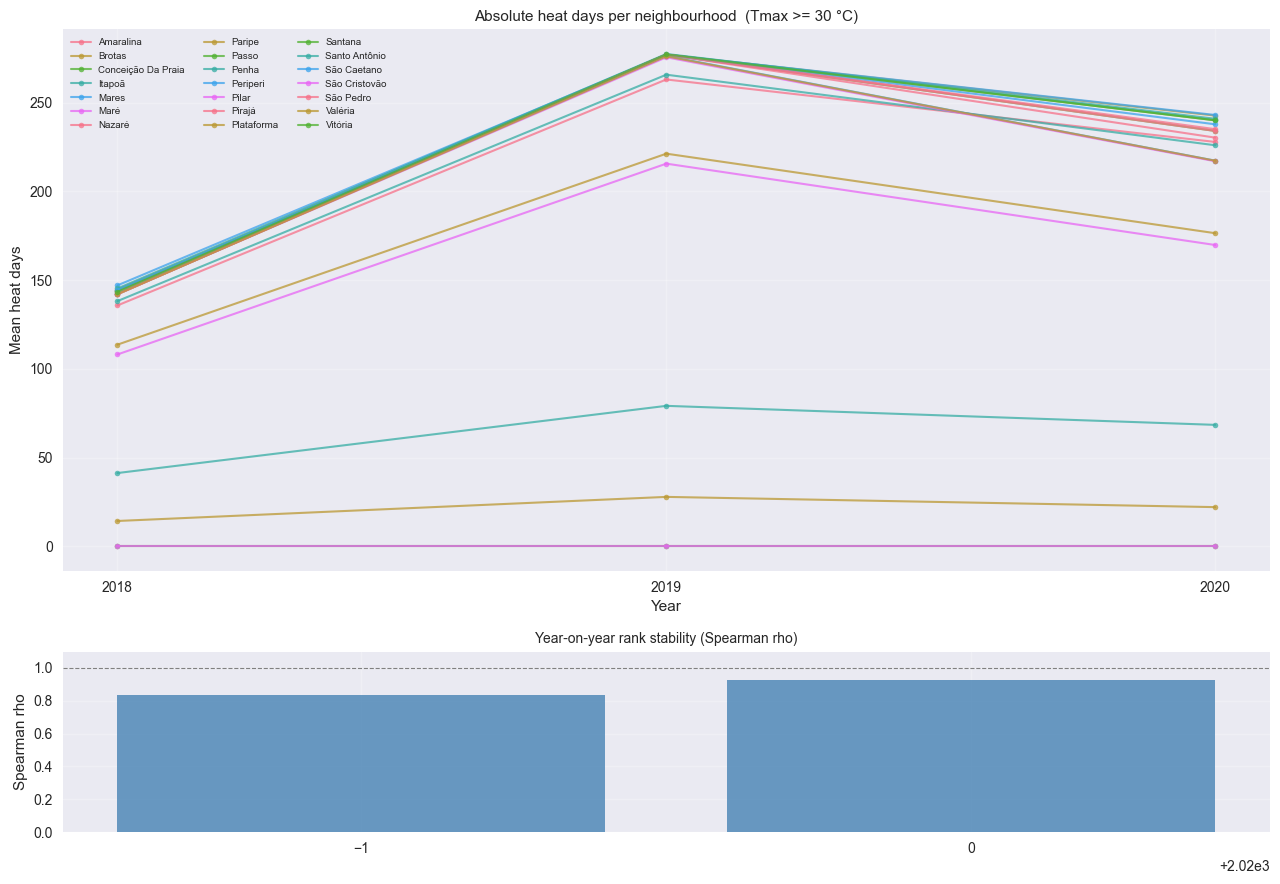

Heat days by neighbourhood:
name  Amaralina  Brotas  Conceição Da Praia  Itapoã  Mares   Maré  Nazaré  Paripe  Passo  Penha  Periperi  Pilar  Pirajá  Plataforma  Santana  Santo Antônio  São Caetano  São Cristovão  São Pedro  Valéria  Vitória
year                                                                                                                                                                                                                 
2018      135.7   144.6               142.0   138.1  147.0  108.1   142.0    14.3    0.0   41.3     142.4    0.0   143.6       113.6    144.0          145.2        144.4          142.3      142.0    142.1    143.4
2019      263.0   277.0               277.0   265.7  277.0  215.6   277.0    27.9    0.0   79.1     276.2    0.0   277.0       221.2    277.0          277.4        276.9          275.5      277.0    276.1    277.1
2020      227.8   242.6               234.0   225.9  243.0  169.8   234.0    22.1    0.0   68.4     217.2    0.0   2

In [22]:
def plot_neighbourhood_trends(da_tmax, gdf, threshold=30.0):
    """
    Line chart: mean absolute heat days per neighbourhood per year.
    Pixel-level counts are averaged to neighbourhood level each year.
    Second panel: year-on-year Spearman rank stability.
    """
    years = sorted(int(y) for y in np.unique(da_tmax.time.dt.year.values))
    if len(years) < 2:
        print('Need at least 2 years of data.')
        return

    records = []
    for yr in years:
        heat_map = compute_absolute_heat_days(da_tmax, yr, threshold)
        nbhd_agg = aggregate_to_neighbourhoods(heat_map, gdf)
        for _, row in nbhd_agg.iterrows():
            if pd.notna(row['mean_heat_days']):
                records.append({'year': yr, 'name': row['name'],
                                'heat_days': row['mean_heat_days']})

    if not records:
        print('No data - check that neighbourhoods overlap the raster extent.')
        return

    pivot = (pd.DataFrame(records)
               .pivot_table(index='year', columns='name',
                            values='heat_days', aggfunc='mean'))

    pivot_years = list(pivot.index)
    rhos, rho_years = [], []
    for i in range(len(pivot_years) - 1):
        a = pivot.loc[pivot_years[i]].dropna()
        b = pivot.loc[pivot_years[i + 1]].dropna()
        common = a.index.intersection(b.index)
        if len(common) >= 2:
            rhos.append(spearmanr(a[common], b[common]).statistic)
        else:
            rhos.append(np.nan)
        rho_years.append(pivot_years[i + 1])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9),
                                   gridspec_kw={'height_ratios': [3, 1]})
    for col in pivot.columns:
        ax1.plot(pivot.index, pivot[col], marker='o', linewidth=1.5,
                 markersize=4, alpha=0.75, label=col)
    ax1.set_title(f'Absolute heat days per neighbourhood  (Tmax >= {threshold:.0f} °C)',
                  fontsize=11)
    ax1.set_ylabel('Mean heat days')
    ax1.set_xlabel('Year')
    ax1.legend(fontsize=7, ncol=3, loc='upper left')
    ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax1.grid(True, alpha=0.25)

    ax2.bar(rho_years, rhos, color='steelblue', alpha=0.8)
    ax2.axhline(1, color='grey', linestyle='--', linewidth=0.8)
    ax2.set_title('Year-on-year rank stability (Spearman rho)', fontsize=10)
    ax2.set_ylabel('Spearman rho')
    ax2.set_ylim(0, 1.1)
    ax2.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax2.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()
    print('Heat days by neighbourhood:')
    print(pivot.round(1).to_string())


plot_neighbourhood_trends(da_tmax, neighbourhoods, threshold=30.0)
